W notebooku przedstawiono kod, który przeprowadza proces uczenia wybranych modeli uczenia maszynowego. Dodatkowo przedstawiono ewaluację wyników oraz optymalizację wybranych modeli.

**[UWAGA]** Ze względu na specyfikę eksperymentów (wymagającą np. selektywnego uruchamiania komórek), kod pełni funkcję dokumentacyjną i nie jest przeznaczony do automatycznego wykonania w trybie ciągłym (przycisk **Run All**).

## Podział i przygotowanie danych

In [19]:
import pandas as pd 
pd.set_option('display.max_columns', None)

df_class = pd.read_csv('../../DATA/processed/new_final_classification_df.csv')
df_reg = pd.read_csv('../../DATA/processed/new_final_regression_df.csv')

In [2]:
df_class.sample()

,song_id,title,artist_name,release,year,popularity_class,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
86248,SOHAXKK12A8C136801,Velocidade,Cesaria Evora,Voz D' Amor,2003,1,5.309102,0.247641,-7.793,1,95.318,0.676808,0.418829,5.633032,-2.92129,32.242616,0.815149,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1


In [3]:
df_reg.sample()

,song_id,title,artist_name,release,year,play_count_log,duration_log,end_of_fade_in_log,loudness,mode,tempo,artist_familiarity,artist_hotttnesss,loudness_max_std,timbre_mean,timbre_std,pitch_variety,is_rock,is_pop,is_jazz,is_electronic,is_hiphop,is_rap,is_metal,is_soul,is_punk,is_classical,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,ts_1,ts_3,ts_4,ts_5,ts_7,has_fade_in,has_fade_out
102420,SOIEKSP12A58A801A0,The Bridge of Fire,Mc Chris,Part Six Part Three,2009,3.295837,5.149602,0.0,-4.968,1,118.581,0.738367,0.542902,6.192549,15.068844,47.617249,1.021508,0,0,1,1,1,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1


Sprawdzenie, czy kolejność w obu plikach jest identyczna.

In [5]:
print(f"Liczba wierszy w klasyfikacji: {len(df_class)}")
print(f"Liczba wierszy w regresji:     {len(df_reg)}")

col_to_check = 'song_id'

if col_to_check in df_class.columns and col_to_check in df_reg.columns:
    are_identical = df_class[col_to_check].equals(df_reg[col_to_check])
    
    if are_identical:
        print(f"\nSUKCES: Kolejność wierszy w kolumnie '{col_to_check}' jest IDEALNIE taka sama.")
    else:
        print(f"\nUWAGA: Kolejność się różni! Musisz to naprawić przed trenowaniem.")
        
        diff = (df_class[col_to_check] != df_reg[col_to_check])
        print(f"Pierwsza różnica występuje w wierszu nr: {diff.idxmax()}")
        print(f"Plik 1: {df_class.loc[diff.idxmax(), col_to_check]}")
        print(f"Plik 2: {df_reg.loc[diff.idxmax(), col_to_check]}")

else:
    print(f"Nie znaleziono kolumny '{col_to_check}' w obu plikach.")

Liczba wierszy w klasyfikacji: 111341
Liczba wierszy w regresji:     111341

SUKCES: Kolejność wierszy w kolumnie 'song_id' jest IDEALNIE taka sama.


Zestaw A: KLASYFIKACJA

In [20]:
from sklearn.model_selection import train_test_split

X_c = df_class.drop(columns=['popularity_class', 'song_id', 'title', 'artist_name', 'release'])
y_c = df_class['popularity_class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=416457)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

Zestaw B: REGRESJA

In [22]:
X_r = df_reg.drop(columns=['play_count_log', 'song_id', 'title', 'artist_name', 'release'])
y_r = df_reg['play_count_log']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=416457)

In [23]:
X_train_r_scaled = scaler.fit_transform(X_train_r) 
X_test_r_scaled = scaler.transform(X_test_r)

In [174]:
print(len(X_train_c), len(X_test_c), len(X_train_r), len(X_test_r))

89072 22269 89072 22269


## Modelowanie

### A: Modele Klasyfikacyjne

In [39]:
c_metrics = []
c_feature_importance = []

#### Regresja Logistyczna

In [40]:
from sklearn.linear_model import LogisticRegression

model_cLogR = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=416457)
model_cLogR.fit(X_train_c_scaled, y_train_c)
y_pred_cLogR = model_cLogR.predict(X_test_c_scaled)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Regresja Logistyczna - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_cLogR, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

Regresja Logistyczna - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.71      0.67      0.69     12002
 Underground       0.42      0.28      0.34      7399
     Popular       0.24      0.30      0.27      2557
       Viral       0.06      0.53      0.11       311

    accuracy                           0.50     22269
   macro avg       0.36      0.45      0.35     22269
weighted avg       0.55      0.50      0.52     22269



In [42]:
import numpy as np

avg_importance = np.mean(np.abs(model_cLogR.coef_), axis=0)
importances_cLogR = pd.Series(avg_importance, index=X_train_c.columns)

for feature_name, importance in importances_cLogR.items():
    c_feature_importance.append({
        'Model': 'Logistic Regression',
        'Feature': feature_name,
        'Importance': importance
    })

print("Logistic Regression - najważniejsze cechy:\n")
print(importances_cLogR.sort_values(ascending=False).head(10))

Logistic Regression - najważniejsze cechy:

artist_hotttnesss     0.420975
artist_familiarity    0.258015
loudness              0.116125
year                  0.092926
is_pop                0.080460
is_metal              0.076903
is_hiphop             0.074800
is_rap                0.065598
ts_7                  0.054558
duration_log          0.049294
dtype: float64


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy_log = accuracy_score(y_test_c, y_pred_cLogR)
precission_log = precision_score(y_test_c, y_pred_cLogR, average='weighted', zero_division=0)
recall_log = recall_score(y_test_c, y_pred_cLogR, average='weighted', zero_division=0)
f1_log = f1_score(y_test_c, y_pred_cLogR, average='weighted', zero_division=0)

c_metrics.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_log,
    'Precision': precission_log,
    'Recall': recall_log,
    'F1 Score': f1_log
})

print('Regresja Logistyczna - metryki:\n')
print(f"Accuracy: {accuracy_log:.4f}\nPrecision: {precission_log:.4f}\nRecall: {recall_log:.4f}\nF1: {f1_log:.4f}")

Regresja Logistyczna - metryki:

Accuracy: 0.4979
Precision: 0.5514
Recall: 0.4979
F1: 0.5167


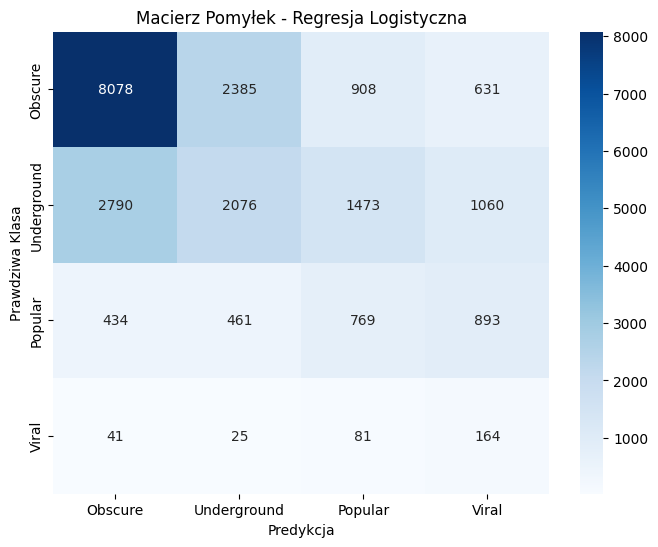

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
cm_cLogR = confusion_matrix(y_test_c, y_pred_cLogR)

# Rysujemy heatmapę
sns.heatmap(cm_cLogR, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])

plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Regresja Logistyczna')
plt.savefig('figures/cm_logistic_regression.png')
plt.show()

#### Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

model_cRF = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=416457)
model_cRF.fit(X_train_c_scaled, y_train_c)
y_pred_cRF = model_cRF.predict(X_test_c_scaled)

In [46]:
print("Random Forest - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_cRF, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

Random Forest - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.66      0.87      0.75     12002
 Underground       0.49      0.37      0.42      7399
     Popular       0.50      0.20      0.29      2557
       Viral       0.67      0.05      0.10       311

    accuracy                           0.61     22269
   macro avg       0.58      0.37      0.39     22269
weighted avg       0.59      0.61      0.58     22269



In [47]:
importances_cRF = pd.Series(model_cRF.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_cRF.items():
    c_feature_importance.append({
        'Model': 'Random Forest Classifier',
        'Feature': feature_name,
        'Importance': importance
    })

print("Random Forest - najważniejsze cechy:\n")
print(importances_cRF.sort_values(ascending=False).head(10))

Random Forest - najważniejsze cechy:

artist_hotttnesss     0.131349
artist_familiarity    0.122470
duration_log          0.067461
loudness              0.065292
timbre_std            0.064681
pitch_variety         0.064635
loudness_max_std      0.064353
timbre_mean           0.064134
tempo                 0.063823
year                  0.052452
dtype: float64


In [48]:
accuracy_rf = accuracy_score(y_test_c, y_pred_cRF)
precission_rf = precision_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)
recall_rf = recall_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)
f1_rf = f1_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)

c_metrics.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precission_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf
})

print('Random Forest - metryki:\n')
print(f"Accuracy: {accuracy_rf:.4f}\nPrecision: {precission_rf:.4f}\nRecall: {recall_rf:.4f}\nF1: {f1_rf:.4f}")

Random Forest - metryki:

Accuracy: 0.6122
Precision: 0.5869
Recall: 0.6122
F1: 0.5782


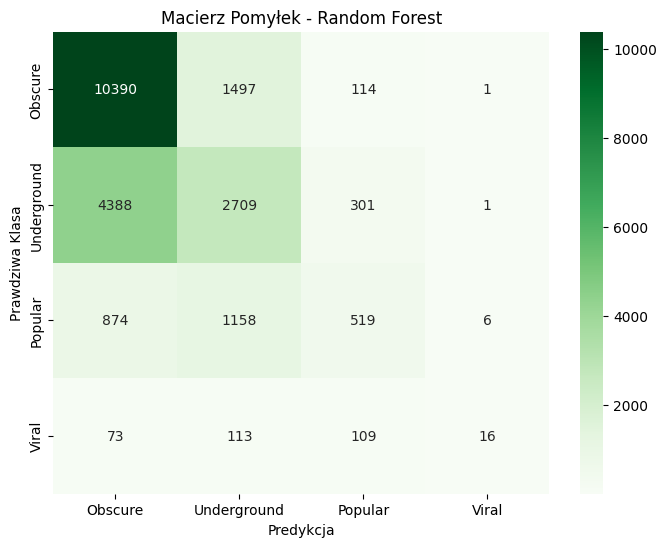

In [49]:
plt.figure(figsize=(8,6))
cm_cRF = confusion_matrix(y_test_c, y_pred_cRF)
sns.heatmap(cm_cRF, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Random Forest')
plt.savefig('figures/cm_random_forest.png')
plt.show()

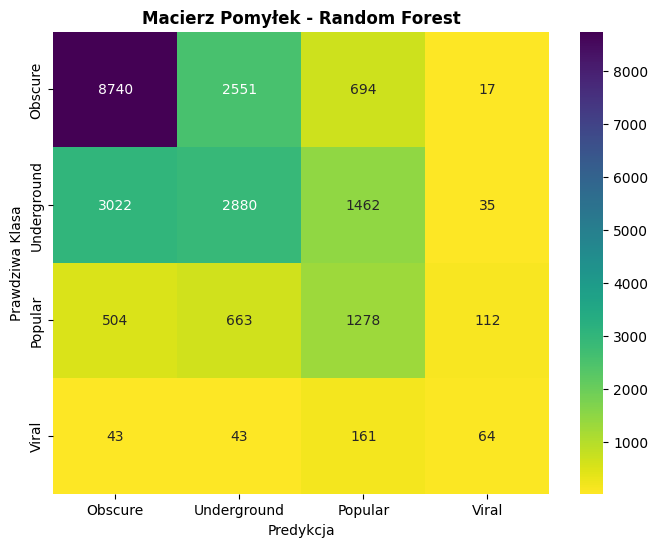

In [83]:
plt.figure(figsize=(8,6))
cm_cRF = confusion_matrix(y_test_c, y_pred_cRF)
sns.heatmap(cm_cRF, annot=True, fmt='d', cmap='viridis_r', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Random Forest', fontweight='bold')
plt.savefig('figures/cm_random_forest.png')
plt.show()

#### Support Vector Machines

In [50]:
from sklearn.svm import SVC
model_cSVM = SVC(kernel='rbf', class_weight='balanced', random_state=416457)
model_cSVM.fit(X_train_c_scaled, y_train_c)
y_pred_cSVM = model_cSVM.predict(X_test_c_scaled)

In [51]:
print("SVM - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_cSVM, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

SVM - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.71      0.67      0.69     12002
 Underground       0.43      0.32      0.37      7399
     Popular       0.28      0.45      0.34      2557
       Viral       0.07      0.30      0.12       311

    accuracy                           0.52     22269
   macro avg       0.37      0.43      0.38     22269
weighted avg       0.56      0.52      0.54     22269



BRAK MOŻLIWOŚCI WYCIĄGNIĘCIA *feature_importance*

In [52]:
accuracy_svm = accuracy_score(y_test_c, y_pred_cSVM)
precission_svm = precision_score(y_test_c, y_pred_cSVM, average='weighted', zero_division=0)
recall_svm = recall_score(y_test_c, y_pred_cSVM, average='weighted', zero_division=0)
f1_svm = f1_score(y_test_c, y_pred_cSVM, average='weighted', zero_division=0)

c_metrics.append({
    'Model': 'Support Vector Machine',
    'Accuracy': accuracy_svm,
    'Precision': precission_svm,
    'Recall': recall_svm,
    'F1 Score': f1_svm
})

print('SVM - metryki:\n')
print(f"Accuracy: {accuracy_svm:.4f}\nPrecision: {precission_svm:.4f}\nRecall: {recall_svm:.4f}\nF1: {f1_svm:.4f}")

SVM - metryki:

Accuracy: 0.5248
Precision: 0.5586
Recall: 0.5248
F1: 0.5357


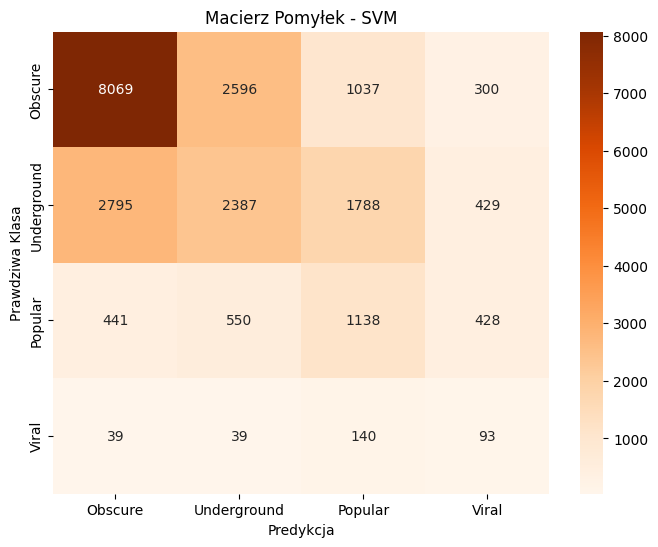

In [53]:
plt.figure(figsize=(8,6))
cm_cSVM = confusion_matrix(y_test_c, y_pred_cSVM)
sns.heatmap(cm_cSVM, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - SVM')
plt.savefig('figures/cm_svm.png')
plt.show()

#### XGBoost

In [54]:
from xgboost import XGBClassifier
model_cXGB = XGBClassifier(eval_metric='mlogloss', random_state=416457)
model_cXGB.fit(X_train_c_scaled, y_train_c)
y_pred_cXGB = model_cXGB.predict(X_test_c_scaled)

In [55]:
print("XGBoost - Raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_cXGB, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

XGBoost - Raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.66      0.84      0.74     12002
 Underground       0.48      0.37      0.42      7399
     Popular       0.46      0.24      0.32      2557
       Viral       0.32      0.06      0.10       311

    accuracy                           0.60     22269
   macro avg       0.48      0.38      0.39     22269
weighted avg       0.58      0.60      0.58     22269



In [56]:
importances_cXGB = pd.Series(model_cXGB.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_cXGB.items():
    c_feature_importance.append({
        'Model': 'XGBoost Classifier',
        'Feature': feature_name,
        'Importance': importance
    })

print("XGBoost - najważniejsze cechy:\n")
print(importances_cXGB.sort_values(ascending=False).head(10))

XGBoost - najważniejsze cechy:

artist_hotttnesss     0.112151
artist_familiarity    0.079805
is_metal              0.045893
is_electronic         0.029826
is_punk               0.029811
is_pop                0.029215
is_soul               0.027736
is_hiphop             0.025170
year                  0.024779
is_rock               0.024542
dtype: float32


In [57]:
accuracy_xgb = accuracy_score(y_test_c, y_pred_cXGB)
precission_xgb = precision_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)
f1_xgb = f1_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)

c_metrics.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_xgb,
    'Precision': precission_xgb,
    'Recall': recall_xgb,
    'F1 Score': f1_xgb
})

print('XGBoost - metryki:\n')
print(f"Accuracy: {accuracy_xgb:.4f}\nPrecision: {precission_xgb:.4f}\nRecall: {recall_xgb:.4f}\nF1: {f1_xgb:.4f}")

XGBoost - metryki:

Accuracy: 0.6047
Precision: 0.5760
Recall: 0.6047
F1: 0.5776


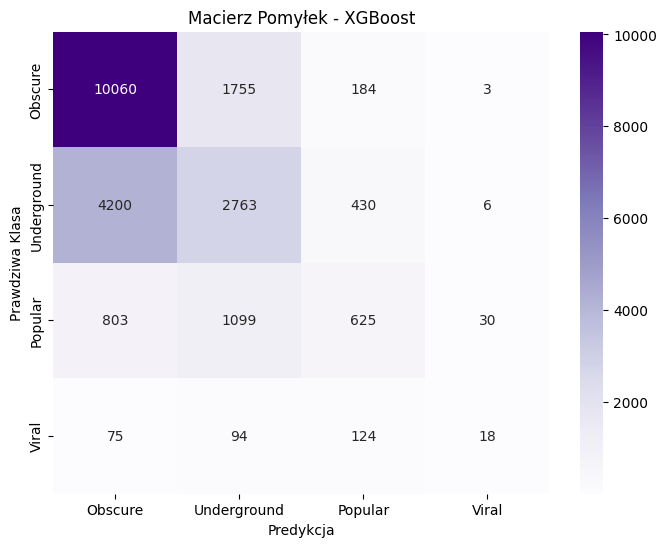

In [58]:
plt.figure(figsize=(8,6))
cm_cXGB = confusion_matrix(y_test_c, y_pred_cXGB)
sns.heatmap(cm_cXGB, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - XGBoost')
plt.savefig('figures/cm_xgboost.png')
plt.show()

#### MLP

In [59]:
from sklearn.neural_network import MLPClassifier
model_cMLP = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=500, early_stopping=True, random_state=416457)
model_cMLP.fit(X_train_c_scaled, y_train_c)
y_pred_cMLP = model_cMLP.predict(X_test_c_scaled)

In [60]:
print("MLP - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_cMLP, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

MLP - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.66      0.84      0.74     12002
 Underground       0.46      0.38      0.42      7399
     Popular       0.44      0.16      0.23      2557
       Viral       0.44      0.01      0.03       311

    accuracy                           0.60     22269
   macro avg       0.50      0.35      0.35     22269
weighted avg       0.57      0.60      0.57     22269



BRAK MOŻLIWOŚCI WYCIĄGNIĘCIA *feature_importance*

In [61]:
accuracy_mlp = accuracy_score(y_test_c, y_pred_cMLP)
precission_mlp = precision_score(y_test_c, y_pred_cMLP, average='weighted', zero_division=0)
recall_mlp = recall_score(y_test_c, y_pred_cMLP, average='weighted', zero_division=0)
f1_mlp = f1_score(y_test_c, y_pred_cMLP, average='weighted', zero_division=0)

c_metrics.append({
    'Model': 'Multi-Layer Perceptron',
    'Accuracy': accuracy_mlp,
    'Precision': precission_mlp,
    'Recall': recall_mlp,
    'F1 Score': f1_mlp
})

print('MLP - metryki:\n')
print(f"Accuracy: {accuracy_mlp:.4f}\nPrecision: {precission_mlp:.4f}\nRecall: {recall_mlp:.4f}\nF1: {f1_mlp:.4f}")

MLP - metryki:

Accuracy: 0.5983
Precision: 0.5675
Recall: 0.5983
F1: 0.5652


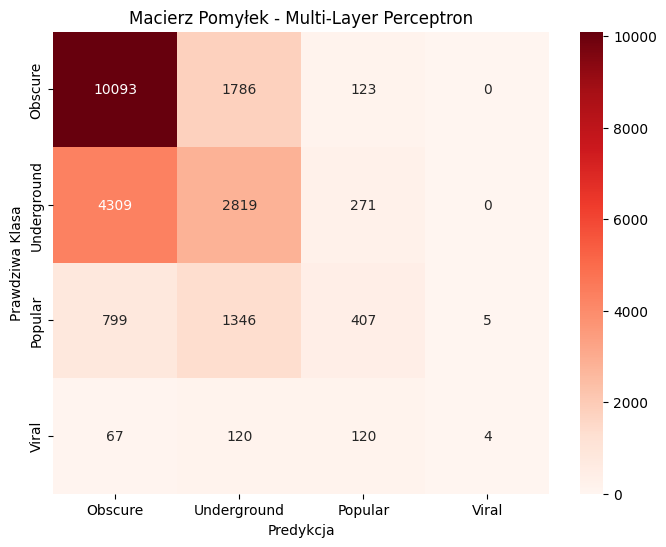

In [62]:
plt.figure(figsize=(8,6))
cm_cMLP = confusion_matrix(y_test_c, y_pred_cMLP)
sns.heatmap(cm_cMLP, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Multi-Layer Perceptron')
plt.savefig('figures/cm_mlp.png')
plt.show()

### B: Modele Regresyjne 

In [ ]:
r_metrics = []
r_feature_importance = []

#### Regresja Liniowa

In [95]:
from sklearn.linear_model import LinearRegression

model_rLinR = LinearRegression()
model_rLinR.fit(X_train_r_scaled, y_train_r)
y_pred_rLinR = model_rLinR.predict(X_test_r_scaled)

In [ ]:
importances_rLinR = pd.Series(model_rLinR.coef_, index=X_train_r.columns)
for feature_name, importance in importances_rLinR.items():
    r_feature_importance.append({
        'Model': 'Linear Regression',
        'Feature': feature_name,
        'Importance': importance
    }) 

print("Regresja Liniowa - najważniejsze cechy:\n")
print(importances_rLinR.sort_values(ascending=False).head(10))

Regresja Liniowa - najważniejsze cechy:

artist_familiarity    0.498489
artist_hotttnesss     0.419579
ts_4                  0.323658
ts_1                  0.212583
ts_3                  0.189300
ts_5                  0.136815
loudness              0.125463
ts_7                  0.090178
is_pop                0.067658
pitch_variety         0.053122
dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

mae_reg = mean_absolute_error(y_test_r, y_pred_rLinR)
rmse_reg = np.sqrt(mean_squared_error(y_test_r, y_pred_rLinR))
mape_reg = np.mean(np.abs((y_test_r - y_pred_rLinR) / y_test_r)) * 100
r2_reg = r2_score(y_test_r, y_pred_rLinR)

r_metrics.append({'Model': 'Linear Regression', 'RMSE': rmse_reg, 'MAE': mae_reg, 'MAPE': mape_reg, 'R2': r2_reg})
print("Regresja Liniowa - metryki:\n")
print(f"MAE: {mae_reg}\nRMSE: {rmse_reg}\nMAPE: {mape_reg}\nR2: {r2_reg}")

Regresja Liniowa - metryki:

MAE: 1.3603625420898566
RMSE: 1.7052527207302588
MAPE: 58.51673402750877
R2: 0.22343889054893695


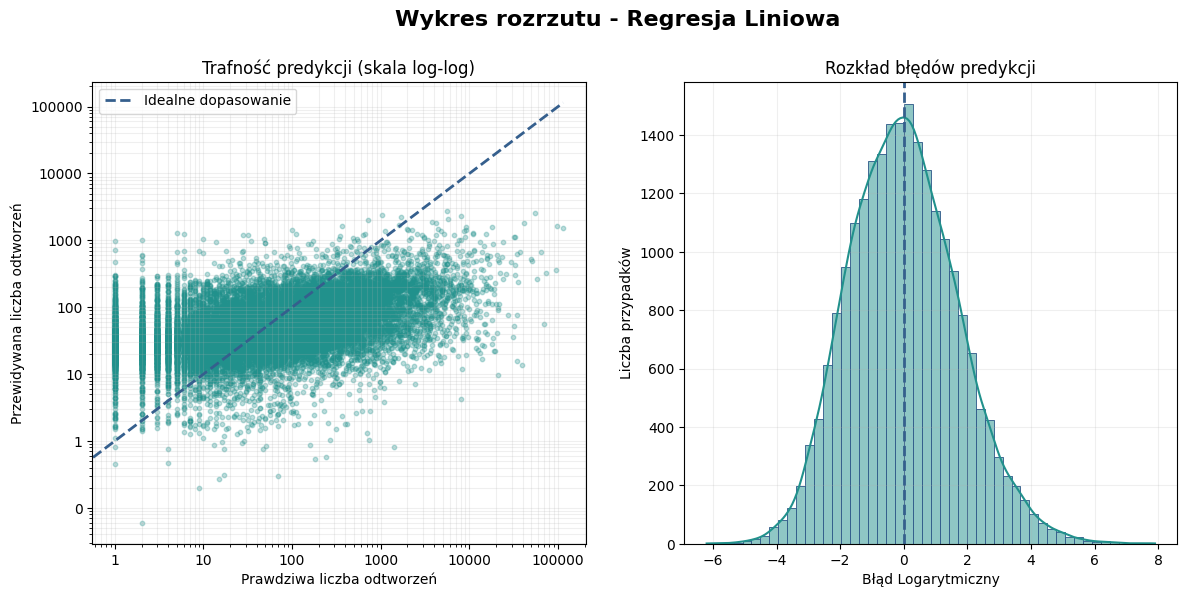

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.cm

color1 = matplotlib.cm.viridis(0.5)
color2 = matplotlib.cm.viridis(0.3)

# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_reg_notlog = np.expm1(y_pred_rLinR)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_reg = y_test_r - y_pred_rLinR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres rozrzutu - Regresja Liniowa', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_reg_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_reg_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_reg_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_reg, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/linear_regression.png')
plt.show()

#### Random Forest

In [84]:
from sklearn.ensemble import RandomForestRegressor

model_rRF = RandomForestRegressor(
    n_estimators=500,        # liczba drzew
    max_depth=20,          
    min_samples_leaf=5,      # większa wartość = mniej overfittingu
    random_state=416457,
    n_jobs=-1                # używa wszystkich rdzeni CPU
)
model_rRF.fit(X_train_r, y_train_r)

y_pred_rRF = model_rRF.predict(X_test_r)

In [85]:
y_pred_rRF = model_rRF.predict(X_test_r)

In [ ]:
importances_rf_reg = pd.Series(model_rRF.feature_importances_, index=X_train_r.columns)
for feature_name, importance in importances_rf_reg.items():
    r_feature_importance.append({
        'Model': 'Random Forest',
        'Feature': feature_name,
        'Importance': importance
    }) 

print("Random Forest - najważniejsze cechy:\n")
print(importances_rf_reg.sort_values(ascending=False).head(10))

NameError: name 'r_feature_importance' is not defined

In [ ]:
mae_rf = mean_absolute_error(y_test_r, y_pred_rRF)
rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rRF))
mape_rf = np.mean(np.abs((y_test_r - y_pred_rRF) / y_test_r)) * 100
r2_rf = r2_score(y_test_r, y_pred_rRF)

r_metrics.append({'Model': 'Random Forest', 'RMSE': rmse_rf, 'MAE': mae_rf, 'MAPE': mape_rf, 'R2': r2_rf})
print("Random Forest - metryki:\n")
print(f"MAE: {mae_rf}\nRMSE: {rmse_rf}\nMAPE: {mape_rf}\nR2: {r2_rf}")

Random Forest - metryki:

MAE: 1.2538960431670076
RMSE: 1.5904255290093403
MAPE: 54.22238578357065
R2: 0.32450084299851534


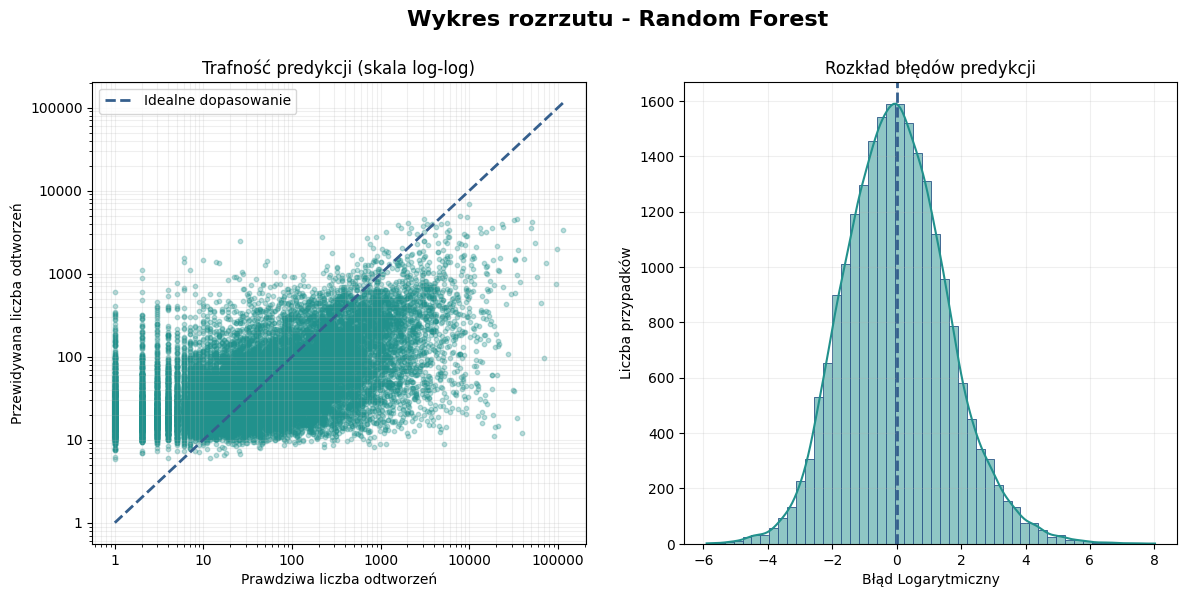

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm
from matplotlib.ticker import ScalarFormatter
color1 = matplotlib.cm.viridis(0.5)
color2 = matplotlib.cm.viridis(0.3)

# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_rf_notlog = np.expm1(y_pred_rRF)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_rf = y_test_r - y_pred_rRF

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres rozrzutu - Random Forest', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_rf_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_rf_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_rf_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_rf, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/random_forest.png')
plt.show()

#### Support Vector Machines

In [102]:
from sklearn.svm import SVR

model_rSVM = SVR(
    kernel='rbf',       # Jądro radialne (standard dla nieliniowych danych)
    C=1.0,              # Regularyzacja (domyślnie 1.0)
    epsilon=0.1         # Margines błędu
    #max_iter=3000      # LIMIT: Przerywa po 3000 iteracjach (dla oszczędności czasu)
)

model_rSVM.fit(X_train_r_scaled, y_train_r)
y_pred_rSVM = model_rSVM.predict(X_test_r_scaled)

BRAK MOŻLIWOŚCI WYCIĄGNIĘCIA *feature_importance*

In [ ]:
mae_svm = mean_absolute_error(y_test_r, y_pred_rSVM)
rmse_svm = np.sqrt(mean_squared_error(y_test_r, y_pred_rSVM))
mape_svm = np.mean(np.abs((y_test_r - y_pred_rSVM) / y_test_r)) * 100
r2_svm = r2_score(y_test_r, y_pred_rSVM)

r_metrics.append({'Model': 'Support Vector Machine', 'RMSE': rmse_svm, 'MAE': mae_svm, 'MAPE': mape_svm, 'R2': r2_svm})
print(f"MAE: {mae_svm}\nRMSE: {rmse_svm}\nMAPE: {mape_svm}\nR2: {r2_svm}")

MAE: 1.321069740150403
RMSE: 1.6786105258726656
MAPE: 55.33059428368755
R2: 0.24751470228249306


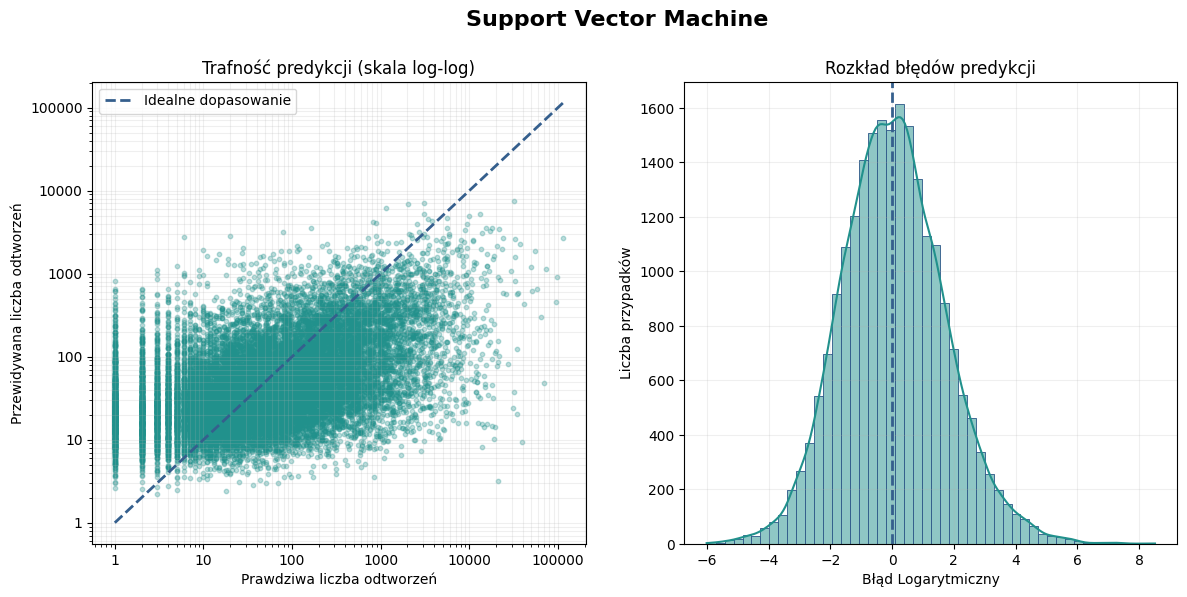

In [103]:
# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_svm_notlog = np.expm1(y_pred_rSVM)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_svm = y_test_r - y_pred_rSVM

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Support Vector Machine', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_svm_notlog, alpha=0.3, color=color1, s=10)
min_val = min(y_test_r_notlog.min(), y_pred_svm_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_svm_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_svm, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/svm.png')
plt.show()

#### XGBoost

In [97]:
from xgboost import XGBRegressor

model_rXGB = XGBRegressor(
    objective='reg:squarederror', # Cel: minimalizacja błędu kwadratowego
    n_estimators=100,             # Liczba drzew
    learning_rate=0.1,            # Szybkość uczenia
    max_depth=6,                  # Głębokość drzewa (złożoność)
    n_jobs=-1,                    # Używa wszystkich rdzeni procesora
    random_state=42
)

model_rXGB.fit(X_train_r, y_train_r)
y_pred_rXGB = model_rXGB.predict(X_test_r)

In [ ]:
y_pred_rXGB = model_rXGB.predict(X_test_r)

In [ ]:
importances_xgb = pd.Series(model_rXGB.feature_importances_, index=X_train_r.columns)
for feature_name, importance in importances_xgb.items():
    r_feature_importance.append({
        'Model': 'XGBoost',
        'Feature': feature_name,
        'Importance': importance
    }) 

print("XGBoost - najważniejsze cechy:\n")
print(importances_xgb.sort_values(ascending=False).head(10))

XGBoost - najważniejsze cechy:

artist_hotttnesss     0.273206
artist_familiarity    0.116868
is_metal              0.043022
is_electronic         0.031834
has_fade_out          0.027450
is_punk               0.026358
is_pop                0.024066
is_soul               0.023347
duration_log          0.022934
is_hiphop             0.022031
dtype: float32


In [ ]:
mae_xgb = mean_absolute_error(y_test_r, y_pred_rXGB)
rmse_xgb = np.sqrt(mean_squared_error(y_test_r, y_pred_rXGB))
mape_xgb = np.mean(np.abs((y_test_r - y_pred_rXGB) / y_test_r)) * 100
r2_xgb = r2_score(y_test_r, y_pred_rXGB)

r_metrics.append({'Model': 'XGBoost', 'RMSE': rmse_xgb, 'MAE': mae_xgb, 'MAPE': mape_xgb, 'R2': r2_xgb})
print("XGBoost - metryki:\n")
print(f"MAE: {mae_xgb}\nRMSE: {rmse_xgb}\nMAPE: {mape_xgb}\nR2: {r2_xgb}")

XGBoost - metryki:

MAE: 1.3041385891419566
RMSE: 1.645817550346425
MAPE: 56.05032758371517
R2: 0.27662830163802554


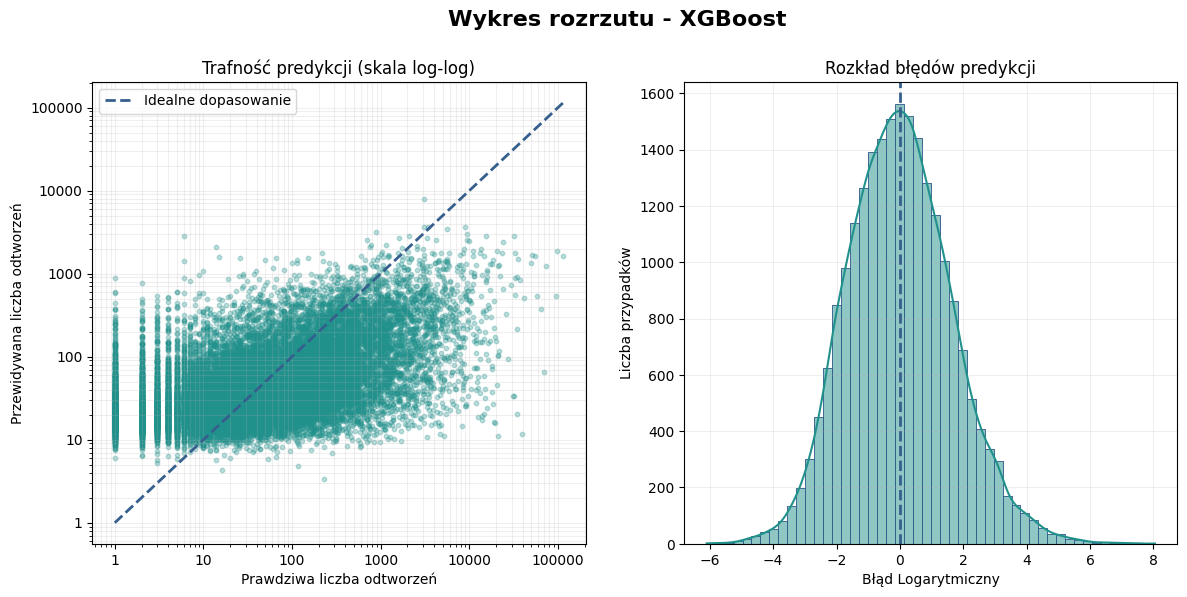

In [105]:
color1 = matplotlib.cm.viridis(0.5)
color2 = matplotlib.cm.viridis(0.3)

# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_xgb_notlog = np.expm1(y_pred_rXGB)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_xgb = y_test_r - y_pred_rXGB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres rozrzutu - XGBoost', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_xgb_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_xgb_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_xgb_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_xgb, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/xgboost.png')
plt.show()

#### MLP

In [100]:
from sklearn.neural_network import MLPRegressor

model_rMLP = MLPRegressor(
    hidden_layer_sizes=(128, 64), # Architektura: 128 neuronów -> 64 neurony
    activation='relu',            # Funkcja aktywacji
    solver='adam',                # Optymalizator
    max_iter=500,                 # Maksymalna liczba epok
    early_stopping=True,          # Ważne: Przerywa trening, jeśli wynik przestaje się poprawiać
    validation_fraction=0.1,      # Część danych wydzielona do sprawdzania early_stopping
    random_state=42
)

model_rMLP.fit(X_train_r_scaled, y_train_r)
y_pred_rMLP = model_rMLP.predict(X_test_r_scaled)

BRAK MOŻLIWOŚCI WYCIĄGNIĘCIA *feature_importance*

In [ ]:
mae_mlp = mean_absolute_error(y_test_r, y_pred_rMLP)
rmse_mlp = np.sqrt(mean_squared_error(y_test_r, y_pred_rMLP))
mape_mlp = np.mean(np.abs((y_test_r - y_pred_rMLP) / y_test_r)) * 100
r2_mlp = r2_score(y_test_r, y_pred_rMLP)

r_metrics.append({'Model': 'Multi-Layer Perceptron', 'RMSE': rmse_mlp, 'MAE': mae_mlp, 'MAPE': mape_mlp, 'R2': r2_mlp})
print("MLP - metryki:\n")
print(f"MAE: {mae_mlp}\nRMSE: {rmse_mlp}\nMAPE: {mape_mlp}\nR2: {r2_mlp}")

MLP - metryki:

MAE: 1.3276371967648966
RMSE: 1.6756149852046138
MAPE: 56.15846964653404
R2: 0.2501979799282603


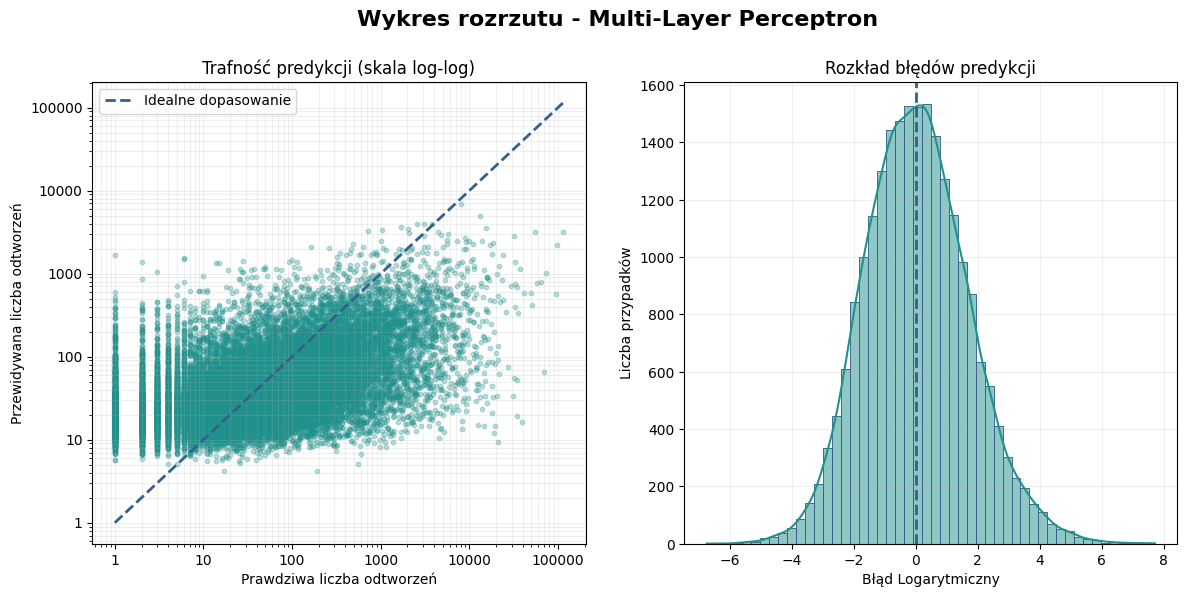

In [106]:
# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_mlp_notlog = np.expm1(y_pred_rMLP)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_mlp = y_test_r - y_pred_rMLP

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres rozrzutu - Multi-Layer Perceptron', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_mlp_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_mlp_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_mlp_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) 
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_mlp, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/mlp.png')
plt.show()

## Porównanie wyników

In [ ]:
import textwrap

### A: Klasyfikacja

#### Metryki

In [ ]:
c_metrics_df = pd.DataFrame(c_metrics)
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241


In [ ]:
# c_metrics_df = c_metrics_df[~c_metrics_df['Model'].str.contains('Ensemble', na=False)]
# c_metrics_df = c_metrics_df.reset_index(drop=True)

# c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.489092,0.536523,0.489092,0.505008
1,Random Forest,0.592040,0.556008,0.592040,0.546932
2,Support Vector Machine,0.514424,0.545737,0.514424,0.522096
3,XGBoost,0.589471,0.555710,0.589471,0.555526
4,Multi-Layer Perceptron,0.584423,0.549230,0.584423,0.548999


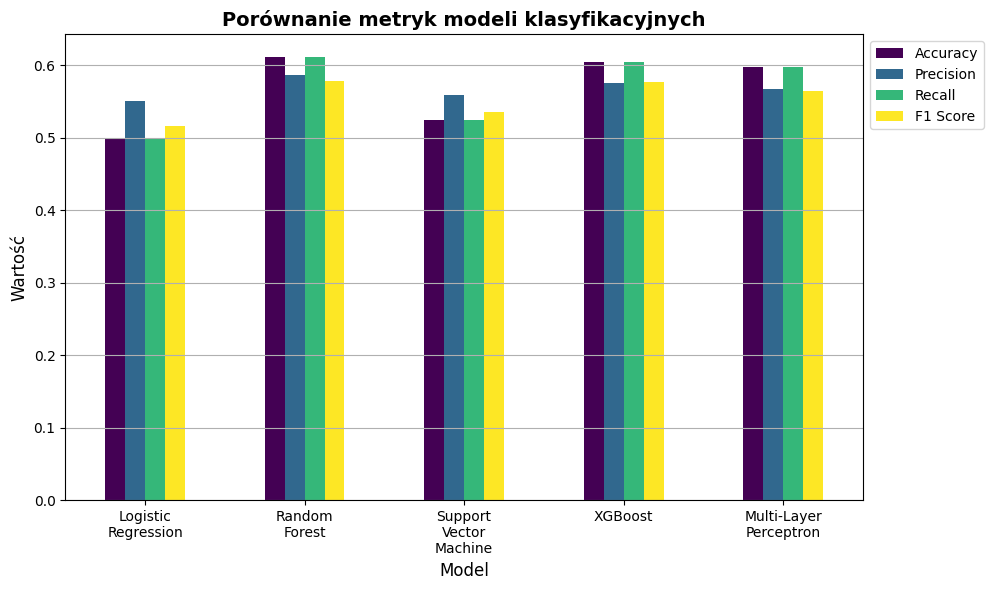

In [ ]:
#plot metrics_df
c_metrics_viz = c_metrics_df.copy()
c_metrics_viz['Model'] = c_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))


c_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
#color = ['skyblue', 'salmon', 'lightgreen']
plt.title('Porównanie metryk modeli klasyfikacyjnych', fontsize=14, fontweight='bold')
plt.ylabel('Wartość', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.16, 1), loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Feature Importance

In [ ]:
c_importance_df = pd.DataFrame(c_feature_importance)
c_importance_df = c_importance_df.sort_values(by='Model', ascending=False)
c_importance_df

,Model,Feature,Importance
119,XGBoost Classifier,has_fade_out,0.017783
99,XGBoost Classifier,is_soul,0.027736
97,XGBoost Classifier,is_rap,0.023755
96,XGBoost Classifier,is_hiphop,0.025170
95,XGBoost Classifier,is_electronic,0.029826
...,...,...,...
26,Logistic Regression,key_D,0.029462
25,Logistic Regression,key_C#,0.008819
24,Logistic Regression,key_C,0.016532
23,Logistic Regression,key_B,0.005671


Pivot table dla lepszej wizualizacji

In [ ]:
c_pivot_df = c_importance_df.pivot_table(
    index='Feature',      
    columns='Model',      
    values='Importance'   
).fillna(0)   

# total importance - sortowanie wg sumy ważności ze wszystkich modeli 
c_pivot_df['Total_Importance'] = c_pivot_df.sum(axis=1)
c_pivot_df = c_pivot_df.sort_values(by='Total_Importance', ascending=False)
c_pivot_df = c_pivot_df.drop(columns='Total_Importance')

c_pivot_df

Model,Logistic Regression,Random Forest Classifier,XGBoost Classifier
Feature,,,
artist_hotttnesss,0.420975,0.131349,0.112151
artist_familiarity,0.258015,0.122470,0.079805
loudness,0.116125,0.065292,0.021636
year,0.092926,0.052452,0.024779
duration_log,0.049294,0.067461,0.023104
is_metal,0.076903,0.009703,0.045893
pitch_variety,0.046269,0.064635,0.021026
timbre_std,0.039988,0.064681,0.020225
is_pop,0.080460,0.007871,0.029215


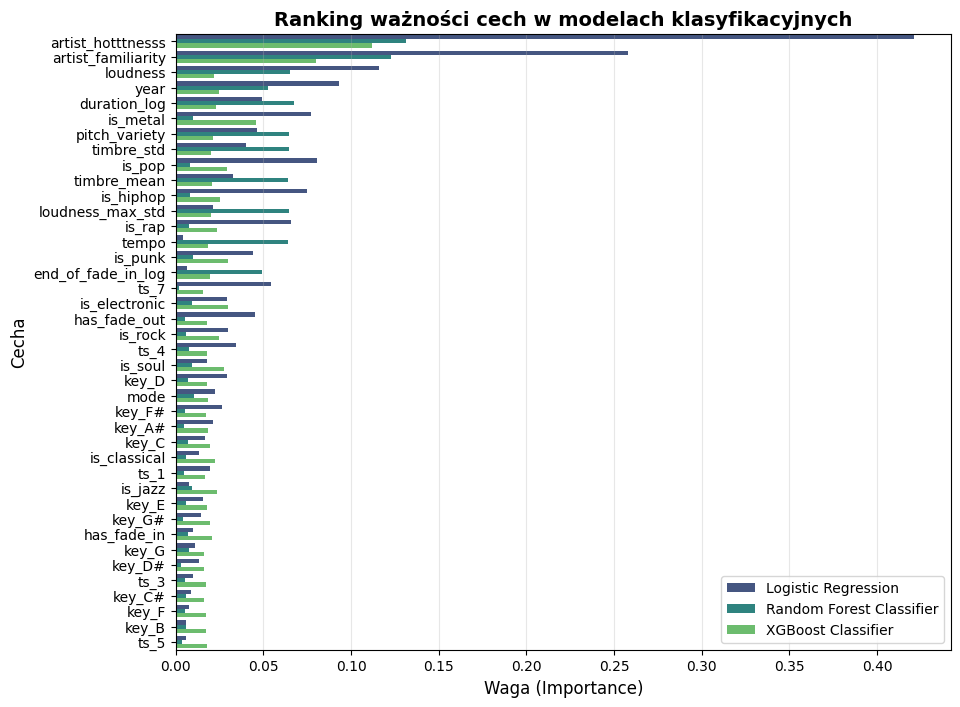

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=c_pivot_df.reset_index().melt(id_vars='Feature', var_name='Model', value_name='Importance'), x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title('Ranking ważności cech w modelach klasyfikacyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Waga (Importance)', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
# show all features from cimportance_df
features = c_importance_df['Feature'].unique()

# Definiujemy kategorie (dodajemy 'structural_features' i 'music_theory')
categories = ['music_theory', 'genre', 'acoustic_features', 'structural_features', 'artist_info']

feature_categories = {}

for feature in features:
    # 1. Metadane Artysty
    if 'artist_' in feature:
        feature_categories[feature] = 'artist_info'
    
    # 2. Gatunki (zmienne one-hot)
    elif 'is_' in feature:
        feature_categories[feature] = 'genre'
        
    # 3. Teoria muzyki (Klucz, Tryb, Metrum)
    # Łączymy key i mode, bo to harmoniczne podstawy
    elif 'key' in feature or 'mode' in feature or 'ts' in feature:
        feature_categories[feature] = 'music_theory'
        
    # 4. Struktura i Czas (To jest Twoja nowa kategoria)
    # Tu wrzucamy wszystko związane z czasem trwania i fade'ami
    elif 'fade' in feature or 'duration' in feature:
        feature_categories[feature] = 'structural_features'
        
    # 5. Cechy Akustyczne (Brzmienie)
    # Tu zostają cechy opisujące "jakość" dźwięku
    elif feature in ['loudness', 'tempo', 'timbre_mean', 'timbre_std', 'loudness_max_std', 'pitch_variety']:
        feature_categories[feature] = 'acoustic_features'
        
    # 6. Zabezpieczenie (jeśli coś pominęliśmy)
    else:
        feature_categories[feature] = feature

# Podgląd, czy wszystko się przypisało
# print(feature_categories)

In [ ]:
c_df_agg = c_importance_df.copy()
c_df_agg['Category'] = c_df_agg['Feature'].map(feature_categories)

c_df_total = c_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

category_order = c_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

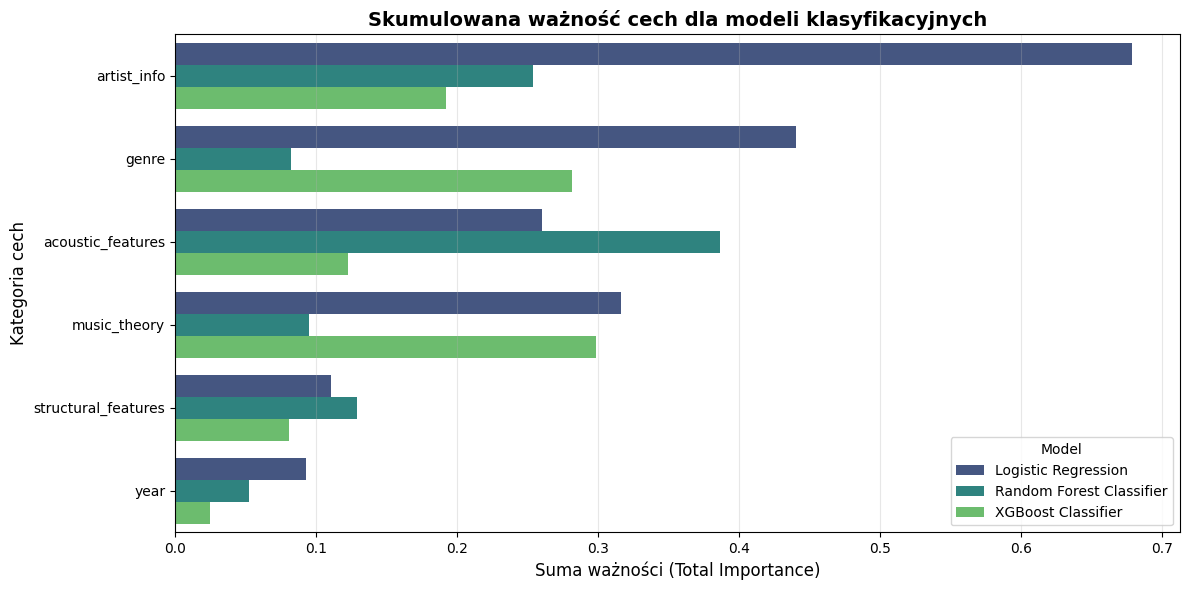

In [ ]:
# wykres
plt.figure(figsize=(12, 6))
sns.barplot(data=c_df_total, x='Importance', y='Category', hue='Model', 
            order=category_order, palette='viridis')
plt.title('Skumulowana ważność cech dla modeli klasyfikacyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Suma ważności (Total Importance)', fontsize=12)
plt.ylabel('Kategoria cech', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Model')
plt.tight_layout()
plt.show()


### B: Regresja

#### Metryki

In [ ]:
r_metrics_df = pd.DataFrame(r_metrics)
r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198


In [ ]:
# r_metrics_df = r_metrics_df[~r_metrics_df['Model'].str.contains('Ensemble', na=False)]
# r_metrics_df = r_metrics_df.reset_index(drop=True)

# r_metrics_df

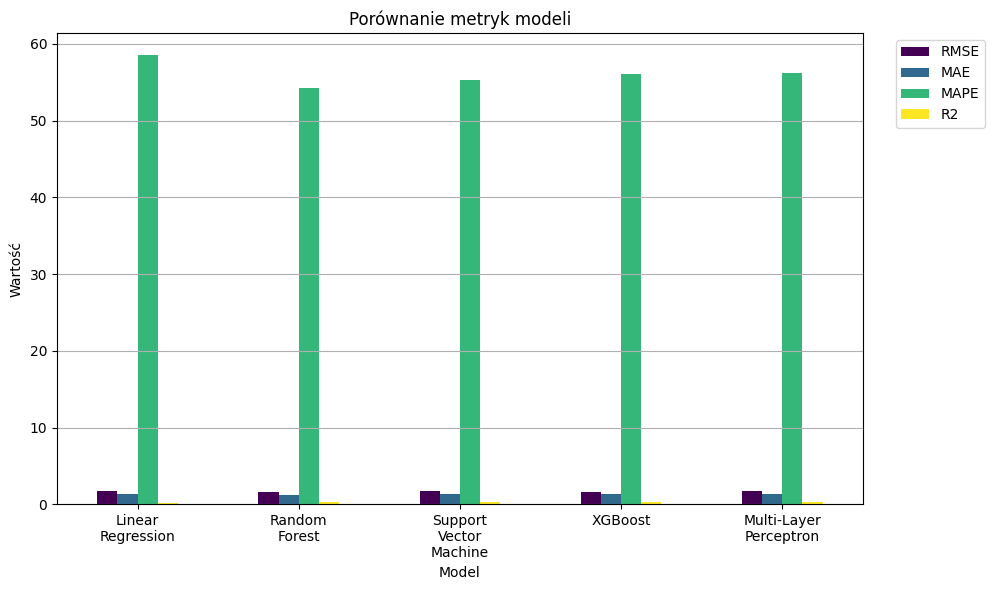

In [ ]:
r_metrics_viz = r_metrics_df.copy()
r_metrics_viz['Model'] = r_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))


r_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Porównanie metryk modeli')
plt.ylabel('Wartość')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1.16, 1), loc='upper right')
plt.tight_layout()
plt.show()

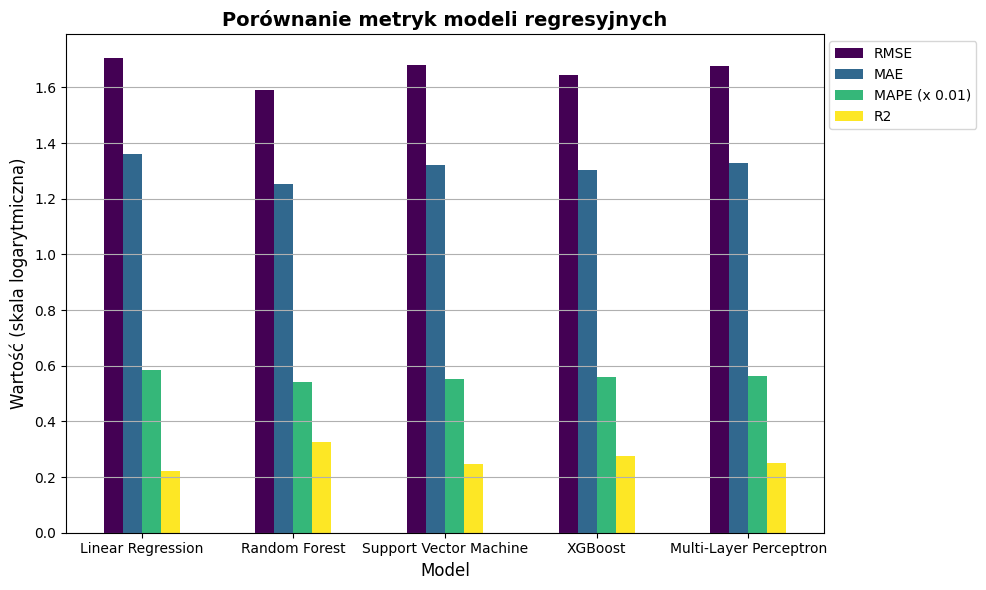

In [ ]:
r_metrics_viz = r_metrics_df.copy()
r_metrics_viz['MAPE'] = r_metrics_viz['MAPE'] / 100  # konwersja MAPE na ułamek dla wizualizacji
r_metrics_viz = r_metrics_viz.rename(columns={'MAPE': 'MAPE (x 0.01)'})
r_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Porównanie metryk modeli regresyjnych', fontsize=14, fontweight='bold')
plt.ylabel('Wartość (skala logarytmiczna)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1.21, 1), loc='upper right')
plt.tight_layout()
plt.show()

#### Feature Importance

In [ ]:
r_importance_df = pd.DataFrame(r_feature_importance)
r_importance_df = r_importance_df.sort_values(by='Model', ascending=False)
r_importance_df

,Model,Feature,Importance
119,XGBoost,has_fade_out,0.027450
99,XGBoost,is_soul,0.023347
97,XGBoost,is_rap,0.019664
96,XGBoost,is_hiphop,0.022031
95,XGBoost,is_electronic,0.031834
...,...,...,...
26,Linear Regression,key_D,-0.001848
25,Linear Regression,key_C#,0.003052
24,Linear Regression,key_C,0.010006
23,Linear Regression,key_B,0.008572


Pivot table dla lepszej wizualizacji

In [ ]:
r_pivot_df = r_importance_df.pivot_table(
    index='Feature',      
    columns='Model',      
    values='Importance'   
).fillna(0)   

# total importance - sortowanie wg sumy ważności ze wszystkich modeli 
r_pivot_df['Total_Importance'] = r_pivot_df.sum(axis=1)
r_pivot_df = r_pivot_df.sort_values(by='Total_Importance', ascending=False)
r_pivot_df = r_pivot_df.drop(columns='Total_Importance')

r_pivot_df

Model,Linear Regression,Random Forest,XGBoost
Feature,,,
artist_hotttnesss,0.419579,0.315235,0.273206
artist_familiarity,0.498489,0.159463,0.116868
ts_4,0.323658,0.004098,0.016053
ts_1,0.212583,0.001689,0.009439
ts_3,0.189300,0.001696,0.012708
loudness,0.125463,0.051835,0.016662
ts_5,0.136815,0.000704,0.010245
pitch_variety,0.053122,0.052165,0.016454
duration_log,0.038387,0.060133,0.022934


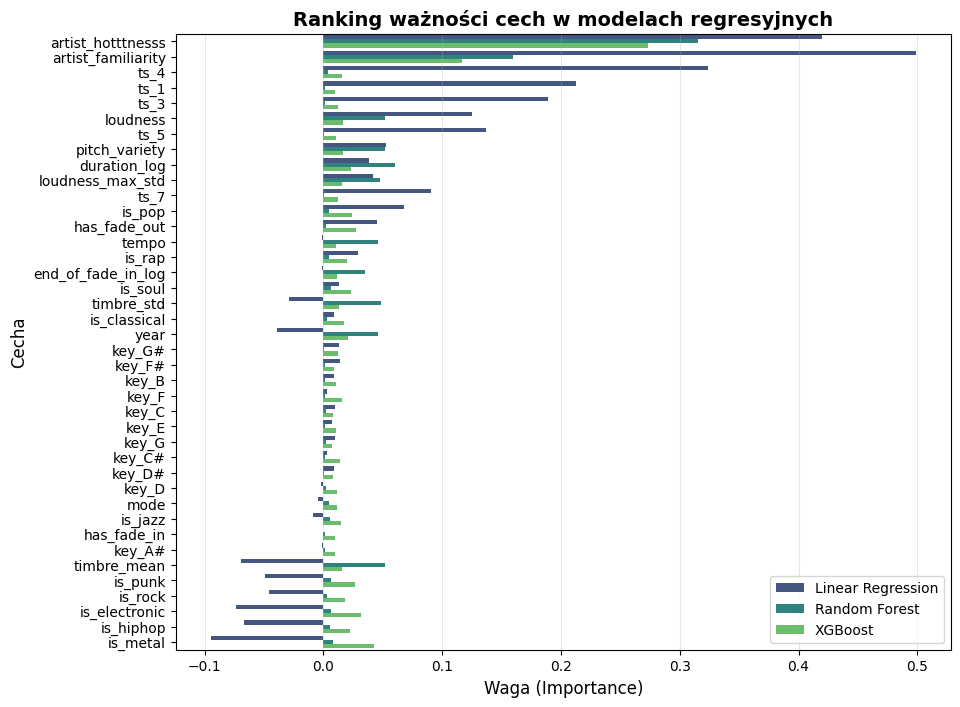

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=r_pivot_df.reset_index().melt(id_vars='Feature', var_name='Model', value_name='Importance'), x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title('Ranking ważności cech w modelach regresyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Waga (Importance)', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
r_df_agg = r_importance_df.copy()
r_df_agg['Category'] = r_df_agg['Feature'].map(feature_categories)

r_df_total = r_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

category_order = r_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

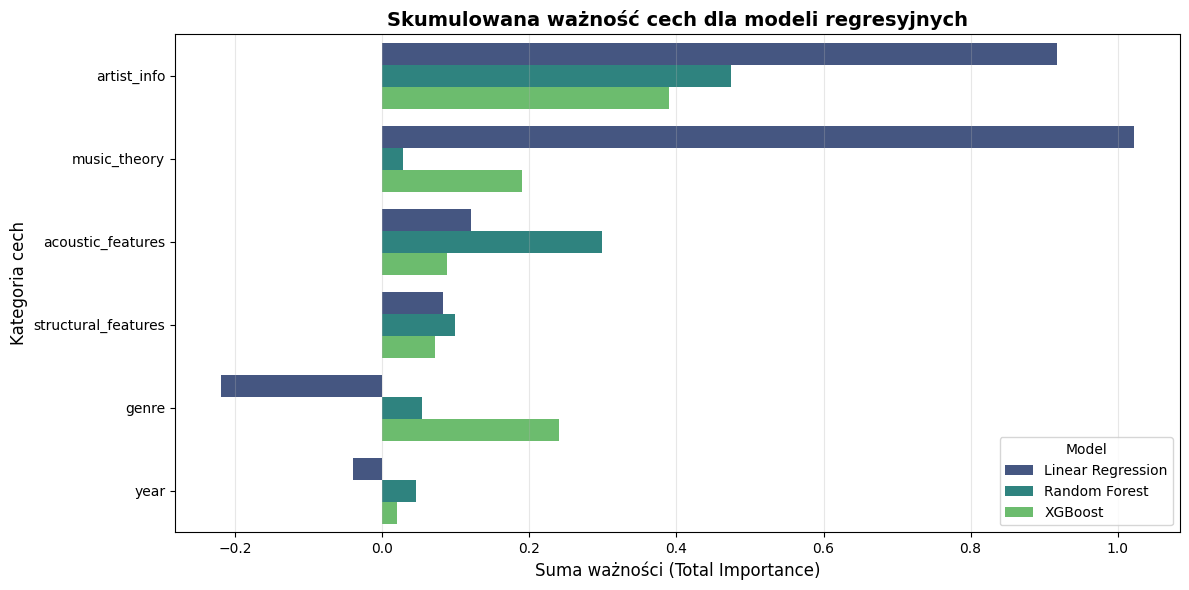

In [ ]:
# wykres
plt.figure(figsize=(12, 6))
sns.barplot(data=r_df_total, x='Importance', y='Category', hue='Model', 
            order=category_order, palette='viridis')
plt.title('Skumulowana ważność cech dla modeli regresyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Suma ważności (Total Importance)', fontsize=12)
plt.ylabel('Kategoria cech', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()


# Ensemble

## Podejście I - LR+RF+XGBoost

### A: Klasyfikacja

In [64]:
from sklearn.ensemble import VotingClassifier

# Tworzymy zespół
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', model_cXGB), 
        ('rf', model_cRF), 
        ('log', model_cLogR)
    ],
    voting='soft' # 'soft' jest zazwyczaj lepsze, ale wymaga, żeby modele umiały zwracać prawdopodobieństwo
)
voting_clf.fit(X_train_c_scaled, y_train_c)

y_pred_voting_c = voting_clf.predict(X_test_c_scaled)

In [65]:
print("Ensemble klasyfikacyjny - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_voting_c, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

Ensemble klasyfikacyjny - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.67      0.84      0.75     12002
 Underground       0.50      0.37      0.43      7399
     Popular       0.45      0.31      0.37      2557
       Viral       0.29      0.14      0.19       311

    accuracy                           0.61     22269
   macro avg       0.48      0.42      0.43     22269
weighted avg       0.59      0.61      0.59     22269



In [66]:
accuracy_ens = accuracy_score(y_test_c, y_pred_voting_c)
precision_ens = precision_score(y_test_c, y_pred_voting_c, average='weighted', zero_division=0)
recall_ens = recall_score(y_test_c, y_pred_voting_c, average='weighted', zero_division=0)
f1_ens = f1_score(y_test_c, y_pred_voting_c, average='weighted', zero_division=0)

print('Ensemble klasyfikacyjny - metryki:\n')
print(f"Accuracy: {accuracy_ens:.4f}\nPrecision: {precision_ens:.4f}\nRecall: {recall_ens:.4f}\nF1: {f1_ens:.4f}")

Ensemble klasyfikacyjny - metryki:

Accuracy: 0.6116
Precision: 0.5859
Recall: 0.6116
F1: 0.5891


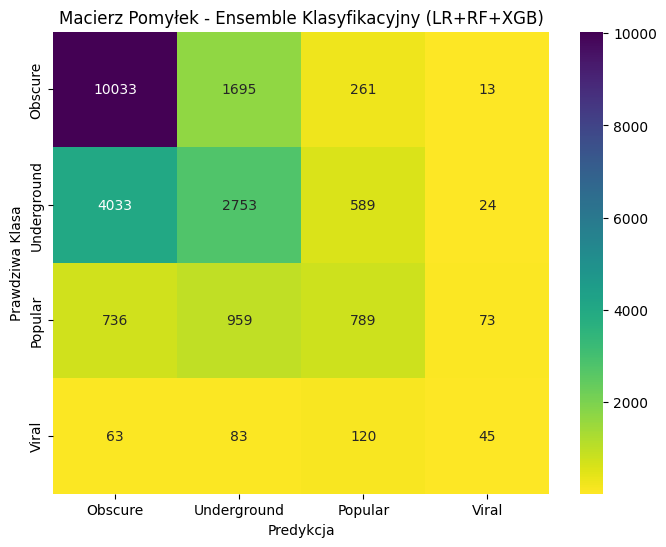

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
cm_ens = confusion_matrix(y_test_c, y_pred_voting_c)

# Rysujemy heatmapę
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='viridis_r', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])

plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Ensemble Klasyfikacyjny (LR+RF+XGB)')
plt.savefig('figures/cm_ensemble_classifier.png')
plt.show()

Porównanie ensamble z resztą modeli

In [ ]:
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241


In [ ]:
# c_metrics.append({
#     'Model': 'Ensemble Classifier','Accuracy': accuracy_clf,'Precision': precision_clf,'Recall': recall_clf,'F1 Score': f1_clf
# })
# c_metrics_df = pd.DataFrame(c_metrics)

c_metrics_df.loc[5,:] = ['Ensemble Classifier (LR+RF+XGB)', accuracy_ens, precision_ens, recall_ens, f1_ens]
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241
5,Ensemble Classifier (LR+RF+XGB),0.611613,0.585934,0.611613,0.589140


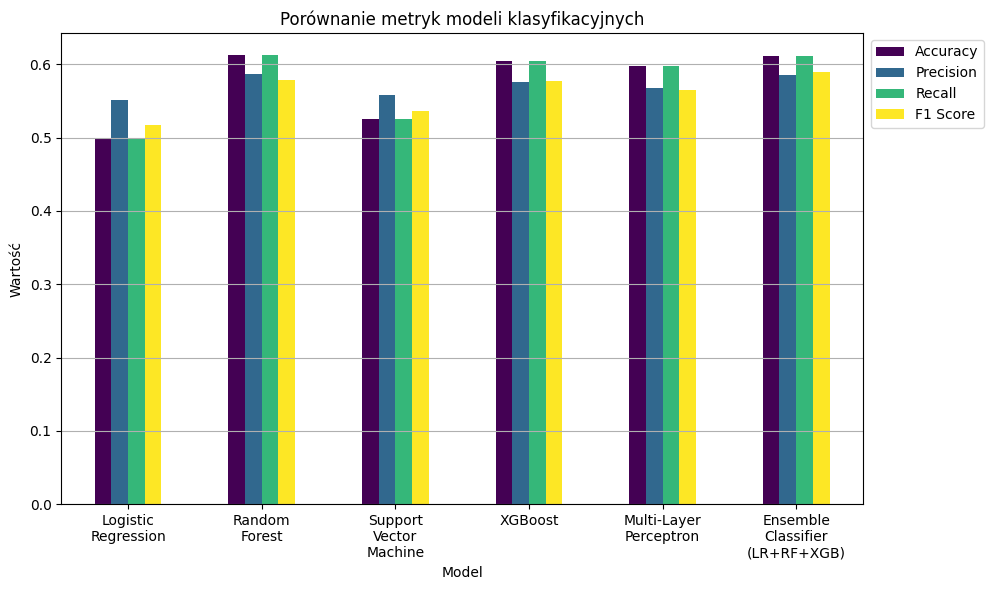

In [ ]:
c_metrics_viz = c_metrics_df.copy()
c_metrics_viz['Model'] = c_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))

c_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
#color = ['skyblue', 'salmon', 'lightgreen']
plt.title('Porównanie metryk modeli klasyfikacyjnych')
plt.ylabel('Wartość')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.16, 1), loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### B: Regresja

In [107]:
from sklearn.ensemble import VotingRegressor

# Tworzymy zespół
voting_reg = VotingRegressor([
    ('xgb', model_rXGB), 
    ('rf', model_rRF), 
    ('lin', model_rLinR)
])

voting_reg.fit(X_train_r_scaled, y_train_r)
y_pred_voting_r = voting_reg.predict(X_test_r_scaled)

In [ ]:
mae_ens = mean_absolute_error(y_test_r, y_pred_voting_r)
rmse_ens = np.sqrt(mean_squared_error(y_test_r, y_pred_voting_r))
mape_ens = np.mean(np.abs((y_test_r - y_pred_voting_r) / y_test_r)) * 100
r2_ens = r2_score(y_test_r, y_pred_voting_r)

r_metrics.append({'Model': 'Ensemble Regressor', 'RMSE': rmse_ens, 'MAE': mae_ens, 'MAPE': mape_ens, 'R2': r2_ens})
print("Ensemble Regresyjny - metryki:\n")
print(f"MAE: {mae_ens}\nRMSE: {rmse_ens}\nMAPE: {mape_ens}\nR2: {r2_ens}")

Ensemble Regresyjny - metryki:

MAE: 1.2935948615062351
RMSE: 1.6306211379139621
MAPE: 55.9098078550224
R2: 0.28992492147794846


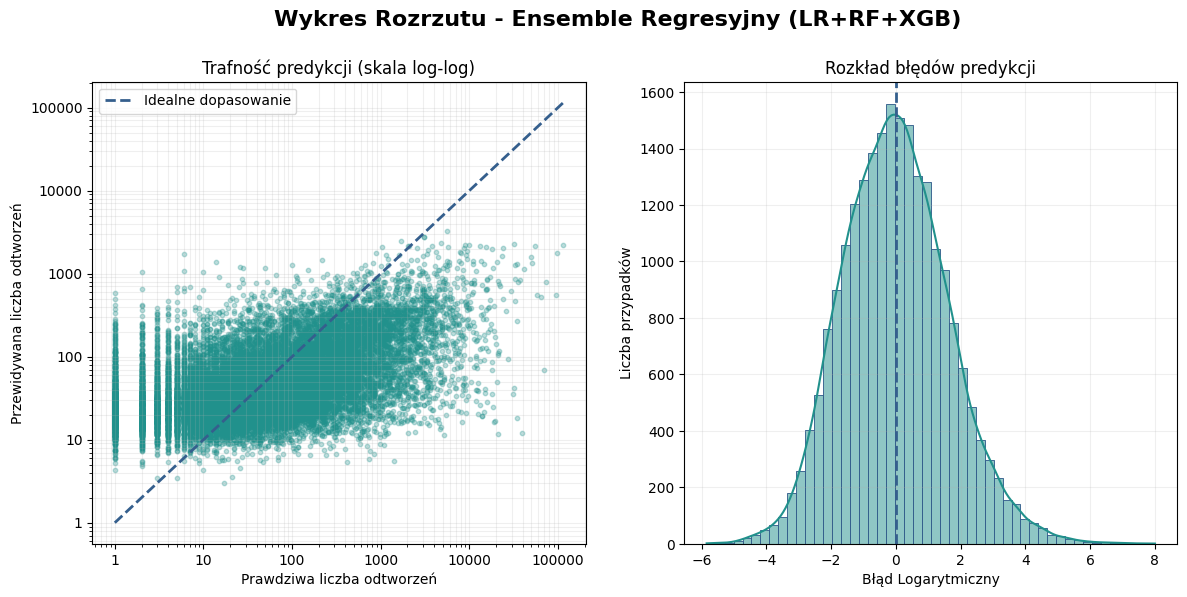

In [108]:
# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_ens_notlog = np.expm1(y_pred_voting_r)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_ens = y_test_r - y_pred_voting_r

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres Rozrzutu - Ensemble Regresyjny (LR+RF+XGB)', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_ens_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_ens_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_ens_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_ens, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/ensemble_regressor.png')
plt.show()

Porównanie wyników z pozostałymi modelami

In [ ]:
r_metrics_df = pd.DataFrame(r_metrics)
r_metrics_df.iloc[5,:] = ['Ensemble Regressor (LR+RF+XGB)', rmse_ens, mae_ens, mape_ens, r2_ens]

In [ ]:
r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198
5,Ensemble Regressor (LR+RF+XGB),1.630621,1.293595,55.909808,0.289925


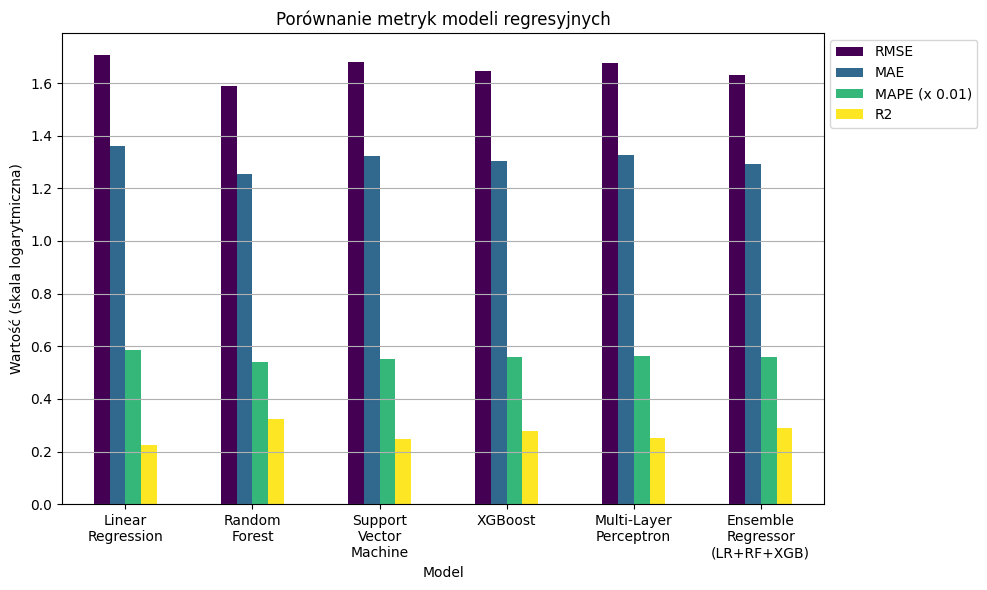

In [ ]:
#r_metrics_df = pd.DataFrame(r_metrics)
r_metrics_viz = r_metrics_df.copy()
r_metrics_viz['MAPE'] = r_metrics_viz['MAPE'] / 100  # konwersja MAPE na ułamek dla wizualizacji
r_metrics_viz = r_metrics_viz.rename(columns={'MAPE': 'MAPE (x 0.01)'})
r_metrics_viz['Model'] = r_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))
r_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Porównanie metryk modeli regresyjnych')
plt.ylabel('Wartość (skala logarytmiczna)')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1.21, 1), loc='upper right')
plt.tight_layout()
plt.show()

## Podejście II - RF+XGBoost

### A: Klasyfikacja

In [68]:
from sklearn.ensemble import VotingClassifier

voting_clf_2 = VotingClassifier(
    estimators=[
        ('xgb', model_cXGB), 
        ('rf', model_cRF), 
    ],
    voting='soft' # 'soft' jest zazwyczaj lepsze, ale wymaga, żeby modele umiały zwracać prawdopodobieństwo
)
voting_clf_2.fit(X_train_c_scaled, y_train_c)

y_pred_voting_c_2 = voting_clf_2.predict(X_test_c_scaled)

In [69]:
print("Ensemble klasyfikacyjny - raport klasyfikacji:\n")
print(classification_report(y_test_c, y_pred_voting_c_2, target_names=['Obscure', 'Underground', 'Popular', 'Viral']))

Ensemble klasyfikacyjny - raport klasyfikacji:

              precision    recall  f1-score   support

     Obscure       0.67      0.86      0.75     12002
 Underground       0.49      0.37      0.42      7399
     Popular       0.49      0.23      0.31      2557
       Viral       0.47      0.05      0.10       311

    accuracy                           0.61     22269
   macro avg       0.53      0.38      0.40     22269
weighted avg       0.59      0.61      0.58     22269



In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_ens_2 = accuracy_score(y_test_c, y_pred_voting_c_2)
precision_ens_2 = precision_score(y_test_c, y_pred_voting_c_2, average='weighted', zero_division=0)
recall_ens_2 = recall_score(y_test_c, y_pred_voting_c_2, average='weighted', zero_division=0)
f1_ens_2 = f1_score(y_test_c, y_pred_voting_c_2, average='weighted', zero_division=0)

print('Ensemble klasyfikacyjny 2 - metryki:\n')
# c_metrics.append({
#     'Model': 'Ensemble Classifier (RF+XGB)','Accuracy': accuracy_ens_2,'Precision': precision_ens_2,'Recall': recall_ens_2,'F1 Score': f1_ens_2
# })
print(f"Accuracy: {accuracy_ens_2:.4f}\nPrecision: {precision_ens_2:.4f}\nRecall: {recall_ens_2:.4f}\nF1: {f1_ens_2:.4f}")

Ensemble klasyfikacyjny 2 - metryki:

Accuracy: 0.6125
Precision: 0.5852
Recall: 0.6125
F1: 0.5819


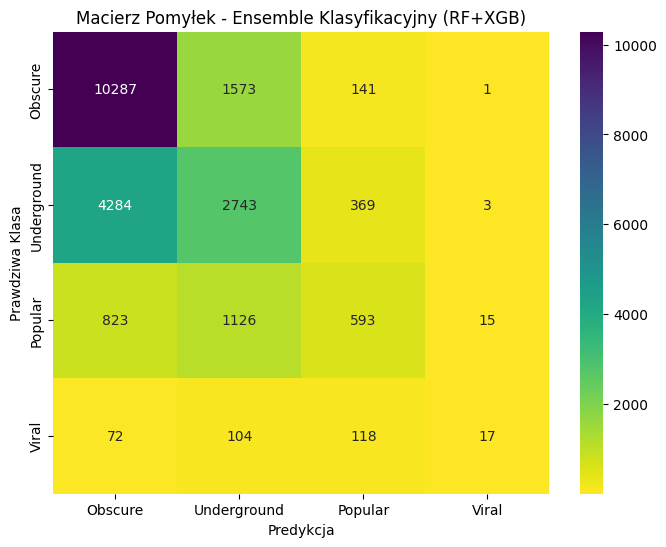

In [71]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8,6))
cm_ens2 = confusion_matrix(y_test_c, y_pred_voting_c_2)

# Rysujemy heatmapę
sns.heatmap(cm_ens2, annot=True, fmt='d', cmap='viridis_r', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])

plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Ensemble Klasyfikacyjny (RF+XGB)')
plt.savefig('figures/cm_ensemble_classifier_2.png')
plt.show()

Porównanie ensamble z resztą modeli

In [ ]:
# c_metrics_df.drop(index=[5,6], inplace=True)

In [ ]:
# c_metrics_df = c_metrics_df.drop(columns=['level_0'], errors='ignore')
# c_metrics_df = c_metrics_df.reset_index(drop=True)
# c_metrics_df

In [ ]:
c_metrics_df.loc[6,:] = ['Ensemble Classifier (RF+XGB)', accuracy_ens_2, precision_ens_2, recall_ens_2, f1_ens_2]
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241
5,Ensemble Classifier (LR+RF+XGB),0.611613,0.585934,0.611613,0.589140
6,Ensemble Classifier (RF+XGB),0.611613,0.585934,0.611613,0.589140


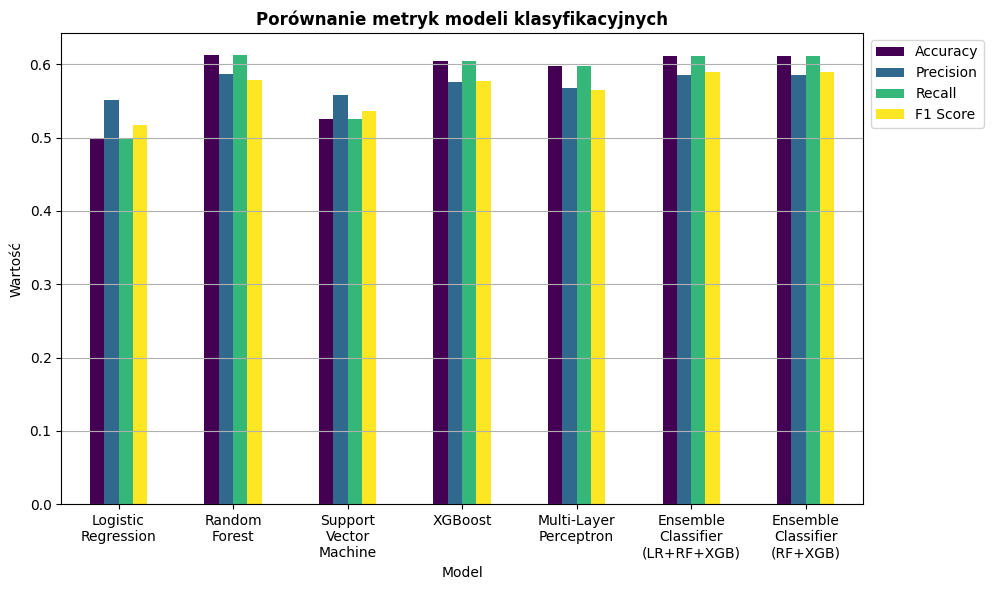

In [ ]:
import textwrap
c_metrics_viz = c_metrics_df.copy()
c_metrics_viz['Model'] = c_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))

c_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
#color = ['skyblue', 'salmon', 'lightgreen']
plt.title('Porównanie metryk modeli klasyfikacyjnych', fontweight='bold')
plt.ylabel('Wartość')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.16, 1), loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### B: Regresja

In [109]:
voting_reg = VotingRegressor([
    ('xgb', model_rXGB), 
    ('rf', model_rRF) 
])

voting_reg.fit(X_train_r_scaled, y_train_r)
y_pred_voting_r_2 = voting_reg.predict(X_test_r_scaled)

In [ ]:
mae_ens_2 = mean_absolute_error(y_test_r, y_pred_voting_r_2)
rmse_ens_2 = np.sqrt(mean_squared_error(y_test_r, y_pred_voting_r_2))
mape_ens_2 = np.mean(np.abs((y_test_r - y_pred_voting_r_2) / y_test_r)) * 100
r2_ens_2 = r2_score(y_test_r, y_pred_voting_r_2)

r_metrics.append({'Model': 'Ensemble Regressor (RF+XGB)', 'RMSE': rmse_ens_2, 'MAE': mae_ens_2, 'MAPE': mape_ens_2, 'R2': r2_ens_2})
print("Ensemble Regresyjny 2 - metryki:\n")
print(f"MAE: {mae_ens_2}\nRMSE: {rmse_ens_2}\nMAPE: {mape_ens_2}\nR2: {r2_ens_2}")

Ensemble Regresyjny 2 - metryki:

MAE: 1.274533570485682
RMSE: 1.6119074265251023
MAPE: 55.045272238849506
R2: 0.3061296542188834


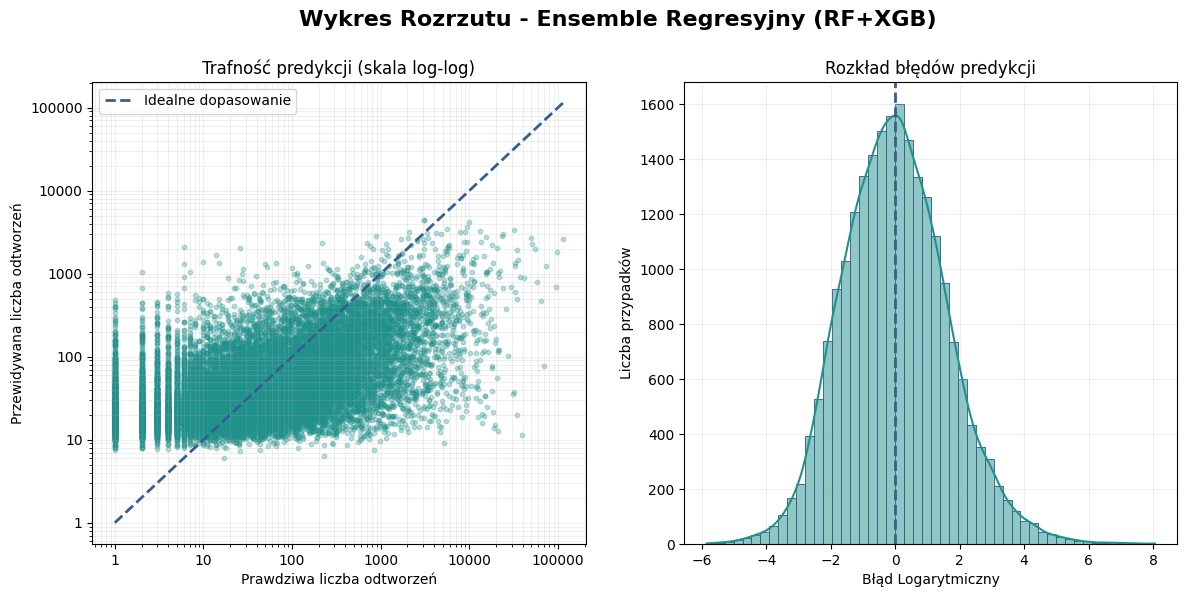

In [110]:
# odlogarytmowanie danych
y_test_r_notlog = np.expm1(y_test_r)
y_pred_voting_r_notlog = np.expm1(y_pred_voting_r_2)

# wyznaczenie błdów na logarytmach (większa stabilność)
errors_ens_2 = y_test_r - y_pred_voting_r_2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wykres Rozrzutu - Ensemble Regresyjny (RF+XGB)', fontsize=16, y=1.0, fontweight='bold')

# WYKRES 1
ax1.scatter(y_test_r_notlog, y_pred_voting_r_notlog, alpha=0.3, color=color1, s=10)

min_val = min(y_test_r_notlog.min(), y_pred_voting_r_notlog.min())
max_val = max(y_test_r_notlog.max(), y_pred_voting_r_notlog.max())
ax1.plot([min_val, max_val], [min_val, max_val], '--', color=color2, linewidth=2, label='Idealne dopasowanie')
ax1.set_xscale('log')
ax1.set_yscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlabel('Prawdziwa liczba odtworzeń')
ax1.set_ylabel('Przewidywana liczba odtworzeń')
ax1.set_title('Trafność predykcji (skala log-log)')
ax1.grid(True, which="both", ls="-", alpha=0.2) # Dodajemy siatkę dla czytelności
ax1.legend()

# błąd logarytmiczny -> pomyłka o rząd wielkości
sns.histplot(errors_ens_2, bins=50, kde=True, color=color1, ax=ax2, edgecolor=color2)
ax2.axvline(x=0, color=color2, linestyle='--', linewidth=2)
ax2.set_xlabel('Błąd Logarytmiczny')
ax2.set_ylabel('Liczba przypadków')
ax2.set_title('Rozkład błędów predykcji')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.savefig('figures/ensemble_regressor_2.png')
plt.show()

Porównanie wyników z pozostałymi modelami

In [ ]:
# r_metrics_df = pd.DataFrame(r_metrics)
# r_metrics_df.iloc[5,0] = 'Ensemble Regressor (LR+RF+XGB)'

In [ ]:
r_metrics_df.loc[7,:] = ['Ensemble Regressor (RF+XGB)', rmse_ens_2, mae_ens_2, mape_ens_2, r2_ens_2]
r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198
5,Ensemble Regressor (LR+RF+XGB),1.630621,1.293595,55.909808,0.289925
7,Ensemble Regressor (RF+XGB),1.611907,1.274534,55.045272,0.306130


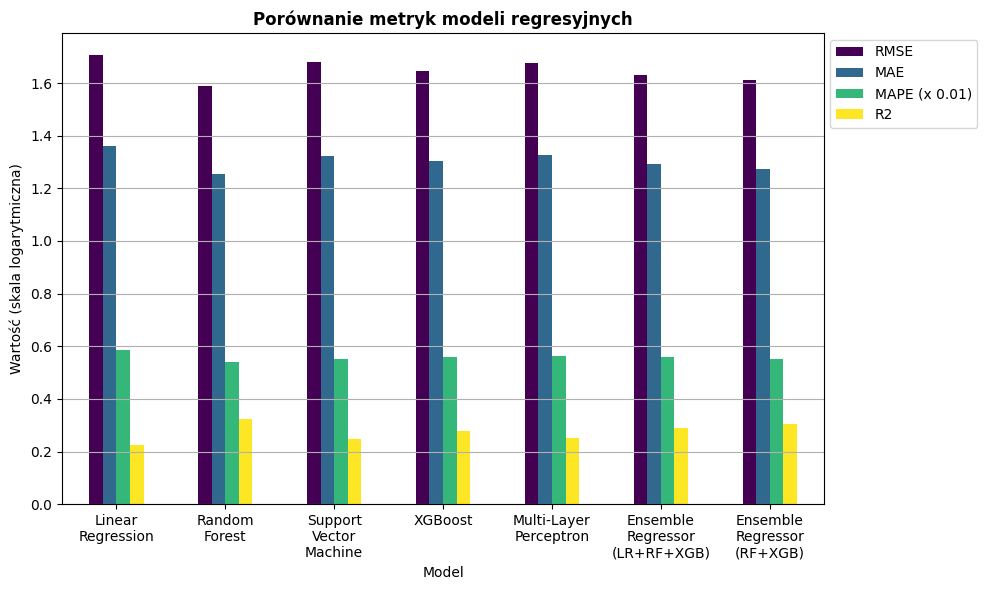

In [ ]:
r_metrics_viz = r_metrics_df.copy()
r_metrics_viz['MAPE'] = r_metrics_viz['MAPE'] / 100  # konwersja MAPE na ułamek dla wizualizacji
r_metrics_viz = r_metrics_viz.rename(columns={'MAPE': 'MAPE (x 0.01)'})
r_metrics_viz['Model'] = r_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))
r_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Porównanie metryk modeli regresyjnych', fontweight='bold')
plt.ylabel('Wartość (skala logarytmiczna)')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1.21, 1), loc='upper right')
plt.tight_layout()
plt.show()

# Tuning hiperparametrów

## Szukanie najlepszego modelu

Aby wybrać najlepszy model, szukamy nie tylko najwyższego score(accuracy lub R2 w zależności od grupy modeli) na zbiorze testowym, ale sprawdzamy również jak model poradzi sobie z zestawem treningowym. 

Jeśli model świetnie uczy się podczas treningu, ale źle radzi sobie z nowymi danymi, można łatwo go stuningować. 

### A: Klasyfikacja

In [ ]:
from sklearn.metrics import accuracy_score

# Lista Twoich modeli klasyfikacyjnych (dodaj te, które masz w pamięci)
models_to_check = {
    'Logistic Regression': (model_cLogR, X_train_c_scaled, X_test_c_scaled),
    'Random Forest': (model_cRF, X_train_c_scaled, X_test_c_scaled), # RF zwykle nie wymaga skalowania, ale nie zaszkodzi
    'XGBoost': (model_cXGB, X_train_c_scaled, X_test_c_scaled),
    'SVM': (model_cSVM, X_train_c_scaled, X_test_c_scaled),
    'MLP': (model_cMLP, X_train_c_scaled, X_test_c_scaled)
}

print(f"{'Model':<20} | {'Train Acc':<10} | {'Test Acc':<10} | {'Różnica (Overfitting)':<10}")
print("-" * 65)

for name, (model, X_tr, X_te) in models_to_check.items():
    # Liczymy wyniki
    train_acc = accuracy_score(y_train_c, model.predict(X_tr))
    test_acc = accuracy_score(y_test_c, model.predict(X_te))
    diff = train_acc - test_acc
    
    print(f"{name:<20} | {train_acc:.4f}     | {test_acc:.4f}     | {diff:.4f}")

Model                | Train Acc  | Test Acc   | Różnica (Overfitting)
-----------------------------------------------------------------
Logistic Regression  | 0.4960     | 0.4979     | -0.0019
Random Forest        | 1.0000     | 0.6122     | 0.3878
XGBoost              | 0.6986     | 0.6047     | 0.0939
SVM                  | 0.5965     | 0.5248     | 0.0717
MLP                  | 0.5996     | 0.5983     | 0.0013


- Idealny kandydat do tuningu (XGBoost / Random Forest):
    - Train: 0.99 (lub bardzo wysoki)
    - Test: 0.60
    - Diagnoza: Model ma ogromny potencjał, ale "zakuwa na pamięć" (Overfitting) -> można poprawić tuningiem

- Solidny średniak (Regresja Liniowa / Logistyczna):
    - Train: 0.62
    - Test: 0.60
    - Diagnoza: Model jest stabilny, ale osiągnął sufit -> tunig nic nie da

- Model słaby (Underfitting):
    - Train: 0.50
    - Test: 0.49
    - Diagnoza: Model jest za głupi na te dane -> tuning rzadko pomaga

### B: Regresja

In [ ]:
from sklearn.metrics import r2_score

models_to_check_reg = {
    'Linear Regression': (model_rLinR, X_train_r_scaled, X_test_r_scaled),
    'Random Forest':     (model_rRF,   X_train_r,        X_test_r),     
    'XGBoost':           (model_rXGB,  X_train_r,        X_test_r),       
    'SVM':               (model_rSVM,  X_train_r_scaled, X_test_r_scaled),
    'MLP':               (model_rMLP,  X_train_r_scaled, X_test_r_scaled)
}

print(f"{'Model':<20} | {'Train R2':<10} | {'Test R2':<10} | {'Różnica (Overfitting)':<10}")
print("-" * 65)

for name, (model, X_tr, X_te) in models_to_check_reg.items():
    try:
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)
        
        train_r2 = r2_score(y_train_r, y_pred_train)
        test_r2 = r2_score(y_test_r, y_pred_test)
        diff = train_r2 - test_r2
        
        print(f"{name:<20} | {train_r2:.4f}     | {test_r2:.4f}     | {diff:.4f}")
    except Exception as e:
        print(f"{name:<20} | BŁĄD: {e}")

Model                | Train R2   | Test R2    | Różnica (Overfitting)
-----------------------------------------------------------------
Linear Regression    | 0.2214     | 0.2234     | -0.0021
Random Forest        | 0.6748     | 0.3245     | 0.3503
XGBoost              | 0.3341     | 0.2766     | 0.0574
SVM                  | 0.3378     | 0.2475     | 0.0902
MLP                  | 0.2732     | 0.2502     | 0.0230


- Duża Różnica (np. Train 0.95 | Test 0.50) -> OVERFITTING (Przeuczenie).
    - Model "zakuł" dane treningowe na pamięć.
    - Co robić: To idealny kandydat do tuningu (zwiększ min_samples_leaf, zmniejsz głębokość drzewa, dodaj regularyzację).

- Mała Różnica, Słabe Wyniki (np. Train 0.45 | Test 0.44) -> UNDERFITTING (Niedouczenie/Sufit).
    - Model jest stabilny, ale po prostu "głupi" lub dane są za słabe.
    - Co robić: Tuning tu niewiele pomoże. Trzeba by lepszych danych.

- Mała Różnica, Dobre Wyniki -> IDEALNIE.

## Poprawione modele

### A: Klasyfikacja

#### Random Forest (tunned)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

c_RF = RandomForestClassifier(class_weight='balanced', random_state=416457)

param_grid_rf_clf = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 16],          
    'min_samples_leaf': [5, 10, 15],   # wymagamy min. 5-15 piosenek w liściu
    'max_features': ['sqrt']
}

grid_rf_c = GridSearchCV(c_RF, param_grid_rf_clf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf_c.fit(X_train_c, y_train_c)

print(f"Najlepsze parametry: {grid_rf_c.best_params_}")
print(f"Najlepsze Accuracy z CV: {grid_rf_c.best_score_:.4f}")

best_rf_c = grid_rf_c.best_estimator_
print(f"Test Accuracy po tuningu: {best_rf_c.score(X_test_c, y_test_c):.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Najlepsze parametry: {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Najlepsze Accuracy z CV: 0.5752
Test Accuracy po tuningu: 0.5821


In [73]:
y_pred_cRF = best_rf_c.predict(X_test_c)

accuracy_cRF = accuracy_score(y_test_c, y_pred_cRF)
precision_cRF = precision_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)
recall_cRF = recall_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)
f1_cRF = f1_score(y_test_c, y_pred_cRF, average='weighted', zero_division=0)

print('Random Forest (tunned) - metryki:\n')
c_metrics.append({
    'Model': 'Random Forest (tunned)','Accuracy': accuracy_cRF,'Precision': precision_cRF,'Recall': recall_cRF,'F1 Score': f1_cRF
})
print(f"Accuracy: {accuracy_cRF:.4f}\nPrecision: {precision_cRF:.4f}\nRecall: {recall_cRF:.4f}\nF1: {f1_cRF:.4f}")

Random Forest (tunned) - metryki:

Accuracy: 0.5821
Precision: 0.5833
Recall: 0.5821
F1: 0.5799


In [74]:
importances_cRFt = pd.Series(best_rf_c.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_cRFt.items():
    c_feature_importance.append({
        'Model': 'Random Forest Classifier (tunned)',
        'Feature': feature_name,
        'Importance': importance
    })

print("Random Forest (tunned) - najważniejsze cechy:\n")
print(importances_cRFt.sort_values(ascending=False).head(10))

Random Forest (tunned) - najważniejsze cechy:

artist_hotttnesss     0.205237
artist_familiarity    0.176408
duration_log          0.060095
loudness              0.057345
pitch_variety         0.054851
timbre_std            0.054722
loudness_max_std      0.054491
timbre_mean           0.052561
tempo                 0.051944
year                  0.047414
dtype: float64


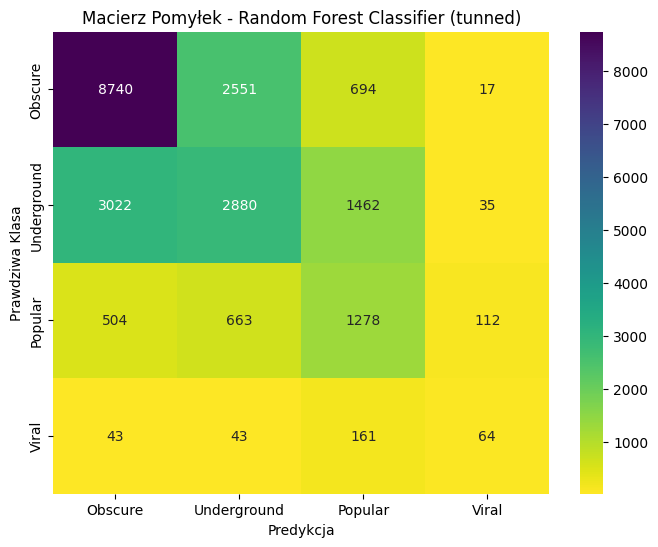

In [75]:
y_pred_cRFt = y_pred_cRF
cm_cRFt = confusion_matrix(y_test_c, y_pred_cRFt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cRFt, annot=True, fmt='d', cmap='viridis_r', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - Random Forest Classifier (tunned)')
plt.savefig('figures/cm_rf_classifier_tunned.png')
plt.show()


#### XGBoost (tunned)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

c_XGB = XGBClassifier(eval_metric='mlogloss', random_state=416457, n_jobs=-1)

param_grid_xgb_clf = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],    # wolniejsza nauka
    'max_depth': [4, 6, 8],           # średnia głębokość
    'subsample': [0.8],               # losowanie próbek
    'colsample_bytree': [0.8]         # losowanie kolumn
}

grid_xgb_c = GridSearchCV(c_XGB, param_grid_xgb_clf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_xgb_c.fit(X_train_c, y_train_c)

print(f"Najlepsze parametry: {grid_xgb_c.best_params_}")
print(f"Najlepsze Accuracy z CV: {grid_xgb_c.best_score_:.4f}")

best_xgb_c = grid_xgb_c.best_estimator_
print(f"Test Accuracy po tuningu: {best_xgb_c.score(X_test_c, y_test_c):.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Najlepsze parametry: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
Najlepsze Accuracy z CV: 0.6041
Test Accuracy po tuningu: 0.6092


In [77]:
y_pred_cXGB = best_xgb_c.predict(X_test_c)

accuracy_cXGB = accuracy_score(y_test_c, y_pred_cXGB)
precision_cXGB = precision_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)
recall_cXGB = recall_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)
f1_cXGB = f1_score(y_test_c, y_pred_cXGB, average='weighted', zero_division=0)

print('XGBoost (tunned) - metryki:\n')
c_metrics.append({
    'Model': 'XGBoost (tunned)','Accuracy': accuracy_cXGB,'Precision': precision_cXGB,'Recall': recall_cXGB,'F1 Score': f1_cXGB
})
print(f"Accuracy: {accuracy_cXGB:.4f}\nPrecision: {precision_cXGB:.4f}\nRecall: {recall_cXGB:.4f}\nF1: {f1_cXGB:.4f}")

XGBoost (tunned) - metryki:

Accuracy: 0.6092
Precision: 0.5814
Recall: 0.6092
F1: 0.5776


In [78]:
importances_cXGBt = pd.Series(best_xgb_c.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_cXGBt.items():
    c_feature_importance.append({
        'Model': 'XGBoost Classifier (tunned)',
        'Feature': feature_name,
        'Importance': importance
    })

print("XGBoost (tunned) - najważniejsze cechy:\n")
print(importances_cXGBt.sort_values(ascending=False).head(10))

XGBoost (tunned) - najważniejsze cechy:

artist_hotttnesss     0.119853
artist_familiarity    0.096680
is_metal              0.039656
is_pop                0.033704
is_electronic         0.031264
is_punk               0.029138
is_hiphop             0.026106
is_soul               0.025617
is_rock               0.025040
year                  0.024764
dtype: float32


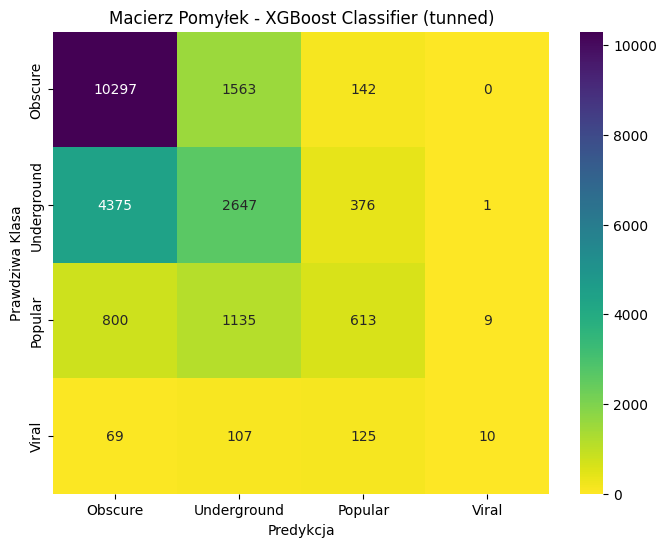

In [79]:
y_pred_cXGBt = y_pred_cXGB
cm_cXGBt = confusion_matrix(y_test_c, y_pred_cXGB)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cXGBt, annot=True, fmt='d', cmap='viridis_r', 
            xticklabels=['Obscure', 'Underground', 'Popular', 'Viral'],
            yticklabels=['Obscure', 'Underground', 'Popular', 'Viral'])
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa Klasa')
plt.title('Macierz Pomyłek - XGBoost Classifier (tunned)')
plt.savefig('figures/cm_xgb_classifier_tunned.png')
plt.show()

### B: Regresja

#### Random Forest (tunned)

In [ ]:
from sklearn.model_selection import GridSearchCV

r_RF = RandomForestRegressor(random_state=4216457)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20],        
    'min_samples_leaf': [4, 8, 12],   
    'max_features': ['sqrt', 0.5]     
}

grid_rf = GridSearchCV(r_RF, param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_r, y_train_r)

print(f"Najlepsze parametry: {grid_rf.best_params_}")
print(f"Najlepszy wynik z CV: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
print(f"Test R2 po tuningu: {best_rf.score(X_test_r, y_test_r):.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Najlepsze parametry: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 4, 'n_estimators': 300}
Najlepszy wynik z CV: 0.3020
Test R2 po tuningu: 0.3214


In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_rRFt = best_rf.predict(X_test_r)

mae_rRFt = mean_absolute_error(y_test_r, y_pred_rRFt)
rmse_rRFt = np.sqrt(mean_squared_error(y_test_r, y_pred_rRFt))
mape_rRFt = np.mean(np.abs((y_test_r - y_pred_rRFt) / y_test_r)) * 100
r2_rRFt = r2_score(y_test_r, y_pred_rRFt)

#r_metrics.append({'Model': 'Random Forest (tunned)', 'RMSE': rmse_rRFt, 'MAE': mae_rRFt, 'MAPE': mape_rRFt, 'R2': r2_rRFt})
print("Random Forest (tunned) - metryki:\n")
print(f"MAE: {mae_rRFt}\nRMSE: {rmse_rRFt}\nMAPE: {mape_rRFt}\nR2: {r2_rRFt}")

Random Forest (tunned) - metryki:

MAE: 1.2579606918690653
RMSE: 1.5941249165625688
MAPE: 54.42741480814557
R2: 0.3213547170936397


In [ ]:
importances_rRFt = pd.Series(best_rf.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_rRFt.items():
    r_feature_importance.append({
        'Model': 'Random Forest Regressor (tunned)',
        'Feature': feature_name,
        'Importance': importance
    })

print("Random Forest Regressor (tunned) - najważniejsze cechy:\n")
print(importances_rRFt.sort_values(ascending=False).head(10))

Random Forest Regressor (tunned) - najważniejsze cechy:

artist_hotttnesss     0.260584
artist_familiarity    0.204485
duration_log          0.058565
loudness              0.052982
pitch_variety         0.051831
timbre_mean           0.051814
timbre_std            0.048461
loudness_max_std      0.048232
tempo                 0.046120
year                  0.045225
dtype: float64


#### XGBoost (tunned)

In [115]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

r_xgb = XGBRegressor(objective='reg:squarederror', random_state=416457, n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [300, 500],      
    'learning_rate': [0.01, 0.05],   
    'max_depth': [3, 5, 7],          
    'subsample': [0.7, 1.0],         
    'colsample_bytree': [0.7, 1.0]   
}

grid_xgb = GridSearchCV(r_xgb, param_grid_xgb, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_r, y_train_r)

print(f"Najlepsze parametry: {grid_xgb.best_params_}")
print(f"Najlepszy wynik z CV: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
print(f"Test R2 po tuningu: {best_xgb.score(X_test_r, y_test_r):.4f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Najlepsze parametry: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Najlepszy wynik z CV: 0.2774
Test R2 po tuningu: 0.2857


In [116]:
y_pred_rXGBt = best_xgb.predict(X_test_r)

mae_rXGBt = mean_absolute_error(y_test_r, y_pred_rXGBt)
rmse_rXGBt = np.sqrt(mean_squared_error(y_test_r, y_pred_rXGBt))
mape_rXGBt = np.mean(np.abs((y_test_r - y_pred_rXGBt) / y_test_r)) * 100
r2_rXGBt = r2_score(y_test_r, y_pred_rXGBt)

#r_metrics.append({'Model': 'XGBoost (tunned)', 'RMSE': rmse_rXGBt, 'MAE': mae_rXGBt, 'MAPE': mape_rXGBt, 'R2': r2_rXGBt})
print("XGBoost (tunned) - metryki:\n")
print(f"MAE: {mae_rXGBt}\nRMSE: {rmse_rXGBt}\nMAPE: {mape_rXGBt}\nR2: {r2_rXGBt}")

XGBoost (tunned) - metryki:

MAE: 1.294691590033241
RMSE: 1.635479733499396
MAPE: 55.685400822217524
R2: 0.28568714076978585


In [ ]:
importances_rXGBt = pd.Series(best_xgb.feature_importances_, index=X_train_c.columns)

for feature_name, importance in importances_rXGBt.items():
    r_feature_importance.append({
        'Model': 'XGBoost Regressor (tunned)',
        'Feature': feature_name,
        'Importance': importance
    })

print("XGBoost Regressor (tunned) - najważniejsze cechy:\n")
print(importances_rXGBt.sort_values(ascending=False).head(10))

XGBoost Regressor (tunned) - najważniejsze cechy:

artist_hotttnesss     0.161249
artist_familiarity    0.132152
is_metal              0.042685
is_electronic         0.040436
is_punk               0.032375
is_pop                0.027835
is_rock               0.027174
is_rap                0.026546
has_fade_out          0.026350
is_hiphop             0.025089
dtype: float32


# Ostateczne porównanie modeli

## A: Klasyfikacja

### Metryki

In [ ]:
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241
5,Ensemble Classifier (LR+RF+XGB),0.611613,0.585934,0.611613,0.589140
6,Ensemble Classifier (RF+XGB),0.611613,0.585934,0.611613,0.589140


In [ ]:
#c_metrics_df.loc[6] = ['Ensemble Classifier (RF+XGB)', accuracy_ens_2, precision_ens_2, recall_ens_2, f1_ens_2]
c_metrics_df.loc[7] = ['Random Forest (tunned)', accuracy_cRF, precision_cRF, recall_cRF, f1_cRF]
c_metrics_df.loc[8] = ['XGBoost (tunned)', accuracy_cXGB, precision_cXGB, recall_cXGB, f1_cXGB]

In [ ]:
c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241
5,Ensemble Classifier (LR+RF+XGB),0.611613,0.585934,0.611613,0.589140
6,Ensemble Classifier (RF+XGB),0.611613,0.585934,0.611613,0.589140
7,Random Forest (tunned),0.582065,0.583347,0.582065,0.579926
8,XGBoost (tunned),0.609233,0.581432,0.609233,0.577616


**[POPRAWA]** Oba modele ensemble miały przypisane te same wartości - błąd w kodzie. Ręcznie naprawiona tabela do poprawienia wizualizacji.

In [ ]:
print(f'{accuracy_ens_2}, {precision_ens_2}, {recall_ens_2}, {f1_ens_2}')

0.6125106650500696, 0.5851702745535944, 0.6125106650500696, 0.5819084678324115


In [119]:
import pandas as pd

# Definicja danych
data = {
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine',
        'XGBoost',
        'Multi-Layer Perceptron',
        'Ensemble Classifier (LR+RF+XGB)',
        'Ensemble Classifier (RF+XGB)',
        'Random Forest (tuned)',
        'XGBoost (tuned)'
    ],
    'Accuracy': [
        0.497867, 0.612241, 0.524810, 0.604697, 
        0.598276, 0.611613, 0.612511, 0.582065, 0.609233
    ],
    'Precision': [
        0.551414, 0.586890, 0.558581, 0.575973, 
        0.567507, 0.585934, 0.585270, 0.583347, 0.581432
    ],
    'Recall': [
        0.497867, 0.612241, 0.524810, 0.604697, 
        0.598276, 0.611613, 0.612511, 0.582065, 0.609233
    ],
    'F1 Score': [
        0.516733, 0.578169, 0.535746, 0.577580, 
        0.565241, 0.589140, 0.581908, 0.579926, 0.577616
    ]
}

# Tworzenie DataFrame
corrected_c_metrics_df = pd.DataFrame(data)
corrected_c_metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.497867,0.551414,0.497867,0.516733
1,Random Forest,0.612241,0.586890,0.612241,0.578169
2,Support Vector Machine,0.524810,0.558581,0.524810,0.535746
3,XGBoost,0.604697,0.575973,0.604697,0.577580
4,Multi-Layer Perceptron,0.598276,0.567507,0.598276,0.565241
5,Ensemble Classifier (LR+RF+XGB),0.611613,0.585934,0.611613,0.589140
6,Ensemble Classifier (RF+XGB),0.612511,0.585270,0.612511,0.581908
7,Random Forest (tuned),0.582065,0.583347,0.582065,0.579926
8,XGBoost (tuned),0.609233,0.581432,0.609233,0.577616


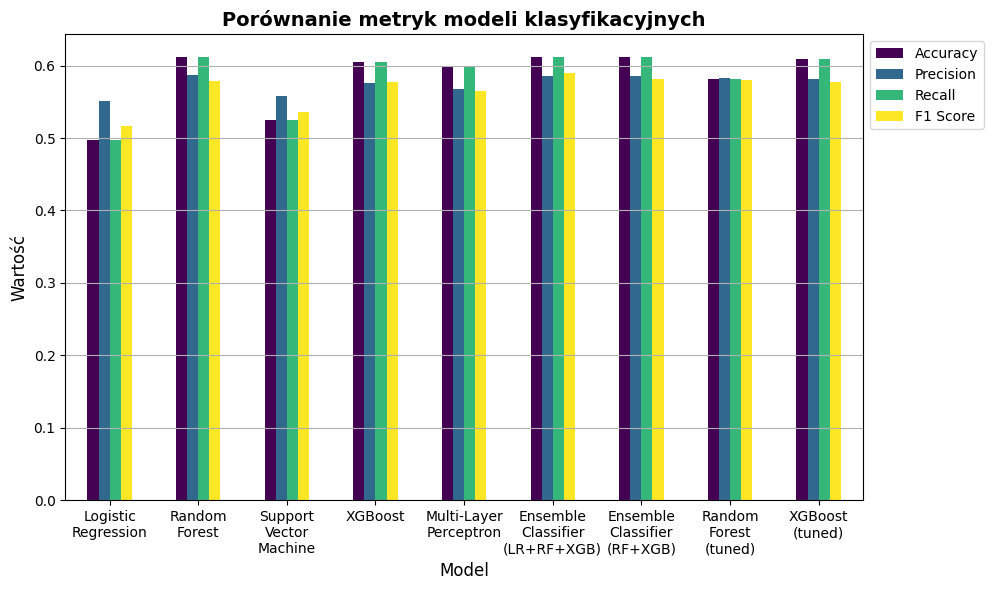

In [120]:
import textwrap
c_metrics_viz = corrected_c_metrics_df.copy()
c_metrics_viz['Model'] = c_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))

c_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')
#color = ['skyblue', 'salmon', 'lightgreen']
plt.title('Porównanie metryk modeli klasyfikacyjnych', fontweight='bold', fontsize=14)
plt.ylabel('Wartość', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.16, 1), loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Feature Importance

In [ ]:
c_feature_importance_df = pd.DataFrame(c_feature_importance)

In [ ]:
c_pivot_df = c_feature_importance_df.pivot_table(
    index='Feature',
    columns='Model',
    values='Importance').fillna(0)

# total importance - sortowanie wg sumy ważności ze wszystkich modeli
c_pivot_df['Total_Importance'] = c_pivot_df.sum(axis=1)
c_pivot_df = c_pivot_df.sort_values(by='Total_Importance', ascending=False)
c_pivot_df = c_pivot_df.drop(columns='Total_Importance')
c_pivot_df = c_pivot_df.drop(columns=['Random Forest Regressor (tunned)', 'XGBoost Regressor (tunned)'], errors='ignore')
c_pivot_df

Model,Logistic Regression,Random Forest Classifier,Random Forest Classifier (tunned),XGBoost Classifier,XGBoost Classifier (tunned)
Feature,,,,,
artist_hotttnesss,0.420975,0.131349,0.205237,0.112151,0.119853
artist_familiarity,0.258015,0.122470,0.176408,0.079805,0.096680
loudness,0.116125,0.065292,0.057345,0.021636,0.021557
year,0.092926,0.052452,0.047414,0.024779,0.024764
duration_log,0.049294,0.067461,0.060095,0.023104,0.023638
pitch_variety,0.046269,0.064635,0.054851,0.021026,0.021035
timbre_std,0.039988,0.064681,0.054722,0.020225,0.019777
timbre_mean,0.032476,0.064134,0.052561,0.020682,0.020512
is_metal,0.076903,0.009703,0.008762,0.045893,0.039656


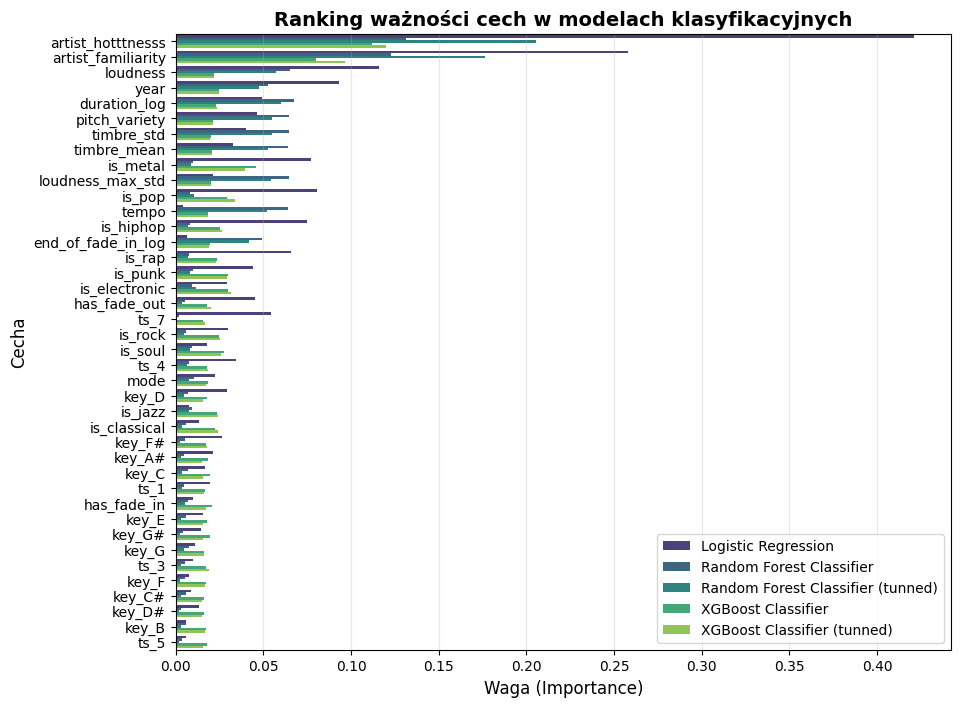

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=c_pivot_df.reset_index().melt(id_vars='Feature', var_name='Model', value_name='Importance'), x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title('Ranking ważności cech w modelach klasyfikacyjnych', fontweight='bold', fontsize=14)
plt.xlabel('Waga (Importance)', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

**[POPRAWA]** błędne tytuły wykresów - ręczne stworzenie pivot_table

In [ ]:
# import pandas as pd

# c_importance_df = c_pivot_df.reset_index().melt(
#     id_vars='Feature', 
#     var_name='Model', 
#     value_name='Importance'
# )

# features = c_importance_df['Feature'].unique()

# # Definiujemy kategorie
# categories = ['music_theory', 'genre', 'acoustic_features', 'structural_features', 'artist_info']

# feature_categories = {}

# for feature in features:
#     # 1. Metadane Artysty
#     if 'artist_' in feature:
#         feature_categories[feature] = 'artist_info'
    
#     # 2. Gatunki (zmienne one-hot)
#     elif 'is_' in feature:
#         feature_categories[feature] = 'genre'
        
#     # 3. Teoria muzyki (Klucz, Tryb, Metrum)
#     elif 'key' in feature or 'mode' in feature or 'ts' in feature:
#         feature_categories[feature] = 'music_theory'
        
#     # 4. Struktura i Czas
#     elif 'fade' in feature or 'duration' in feature:
#         feature_categories[feature] = 'structural_features'
        
#     # 5. Cechy Akustyczne (Brzmienie)
#     elif feature in ['loudness', 'tempo', 'timbre_mean', 'timbre_std', 'loudness_max_std', 'pitch_variety']:
#         feature_categories[feature] = 'acoustic_features'
        
#     # 6. Zabezpieczenie
#     else:
#         feature_categories[feature] = feature  # Np. 'year' trafi tutaj

# c_df_agg = c_importance_df.copy()
# c_df_agg['Category'] = c_df_agg['Feature'].map(feature_categories)

# c_df_total = c_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

# category_order = c_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

In [ ]:
c_df_agg = c_feature_importance_df.copy()
c_df_agg['Category'] = c_df_agg['Feature'].map(feature_categories)

c_df_total = c_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

category_order = c_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

c:\Users\48726\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


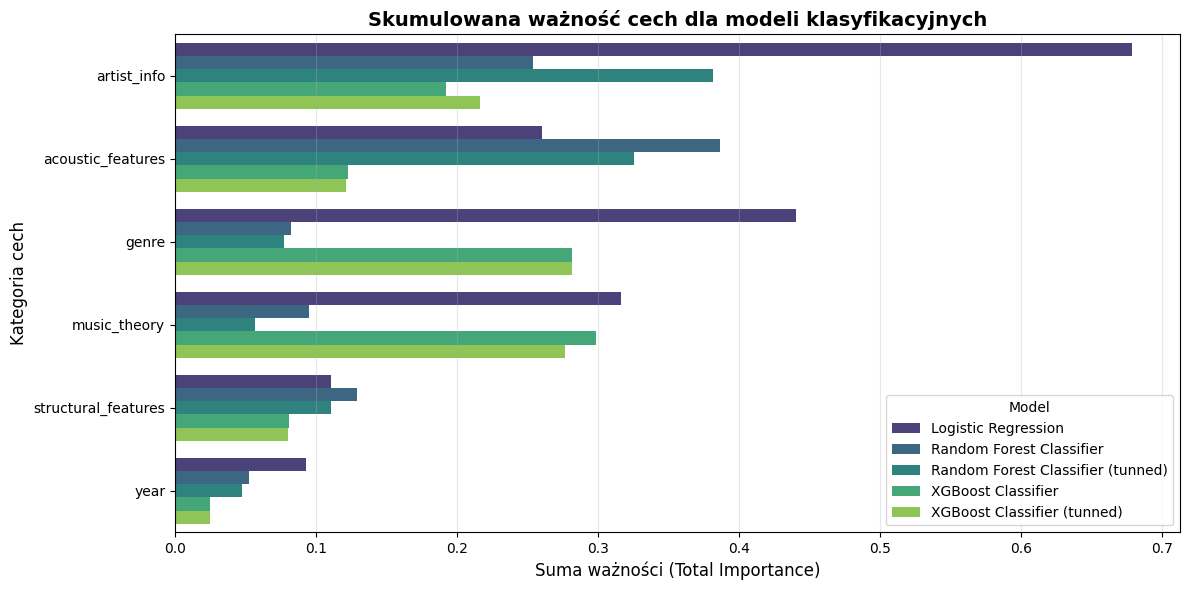

In [ ]:
# wykres
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(data=c_df_total, x='Importance', y='Category', hue='Model', 
            order=category_order, palette='viridis')
plt.title('Skumulowana ważność cech dla modeli klasyfikacyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Suma ważności (Total Importance)', fontsize=12)
plt.ylabel('Kategoria cech', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()


## B: Regresja

#### Metryki

In [ ]:
r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198
5,Ensemble Regressor (LR+RF+XGB),1.630621,1.293595,55.909808,0.289925
7,Ensemble Regressor (RF+XGB),1.611907,1.274534,55.045272,0.306130


In [ ]:
r_metrics_df.loc[6] = ['Ensemble Classifier (RF+XGB)', rmse_ens_2, mae_ens_2,  mape_ens_2, r2_ens_2]
r_metrics_df.loc[7] = ['Random Forest (tunned)', rmse_rRF, mae_rRF, mape_rRF, r2_rRF]
r_metrics_df.loc[8] = ['XGBoost (tunned)', rmse_rXGB, mae_rXGB, mape_rXGB, r2_rXGB]

In [ ]:
r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198
5,Ensemble Regressor (LR+RF+XGB),1.630621,1.293595,55.909808,0.289925
6,Ensemble Classifier (RF+XGB),1.611907,1.274534,55.045272,0.306130
7,Random Forest (tunned),1.594125,1.257961,54.427415,0.321355
8,XGBoost (tunned),1.635480,1.294692,55.685401,0.285687


[POPRAWA] ręczne zdeiniowanie df w celu poprawienia wykresów

In [117]:
import pandas as pd

data = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Support Vector Machine",
        "XGBoost",
        "Multi-Layer Perceptron",
        "Ensemble Regressor (LR+RF+XGB)",
        "Ensemble Classifier (RF+XGB)",
        "Random Forest (tuned)",
        "XGBoost (tuned)"
    ],
    "RMSE": [
        1.705253, 1.590426, 1.678611, 1.645818, 1.675615,
        1.630621, 1.611907, 1.594125, 1.635480
    ],
    "MAE": [
        1.360363, 1.253896, 1.321070, 1.304139, 1.327637,
        1.293595, 1.274534, 1.257961, 1.294692
    ],
    "MAPE": [
        58.516734, 54.222386, 55.330594, 56.050328, 56.158470,
        55.909808, 55.045272, 54.427415, 55.685401
    ],
    "R2": [
        0.223439, 0.324501, 0.247515, 0.276628, 0.250198,
        0.289925, 0.306130, 0.321355, 0.285687
    ]
}

corrected_r_metrics_df = pd.DataFrame(data)
corrected_r_metrics_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,1.705253,1.360363,58.516734,0.223439
1,Random Forest,1.590426,1.253896,54.222386,0.324501
2,Support Vector Machine,1.678611,1.321070,55.330594,0.247515
3,XGBoost,1.645818,1.304139,56.050328,0.276628
4,Multi-Layer Perceptron,1.675615,1.327637,56.158470,0.250198
5,Ensemble Regressor (LR+RF+XGB),1.630621,1.293595,55.909808,0.289925
6,Ensemble Classifier (RF+XGB),1.611907,1.274534,55.045272,0.306130
7,Random Forest (tuned),1.594125,1.257961,54.427415,0.321355
8,XGBoost (tuned),1.635480,1.294692,55.685401,0.285687


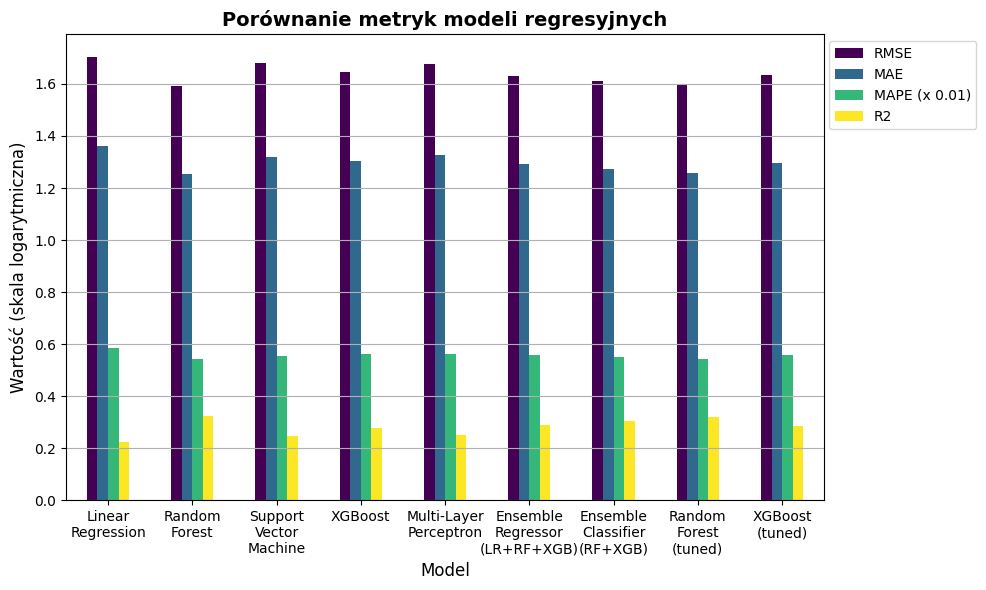

In [118]:
r_metrics_viz = corrected_r_metrics_df.copy()
r_metrics_viz['MAPE'] = r_metrics_viz['MAPE'] / 100  # konwersja MAPE na ułamek dla wizualizacji
r_metrics_viz = r_metrics_viz.rename(columns={'MAPE': 'MAPE (x 0.01)'})
r_metrics_viz['Model'] = r_metrics_viz['Model'].apply(lambda x: textwrap.fill(x, width=12))
r_metrics_viz.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='viridis')

plt.title('Porównanie metryk modeli regresyjnych', fontweight='bold', fontsize=14)
plt.ylabel('Wartość (skala logarytmiczna)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1.21, 1), loc='upper right')
plt.tight_layout()
plt.show()

#### Feature Importance

In [ ]:
r_feature_importance_df = pd.DataFrame(r_feature_importance)

In [ ]:
r_pivot_df = r_feature_importance_df.pivot_table(
    index='Feature',
    columns='Model',
    values='Importance').fillna(0)

# total importance - sortowanie wg sumy ważności ze wszystkich modeli
r_pivot_df['Total_Importance'] = r_pivot_df.sum(axis=1)
r_pivot_df = r_pivot_df.sort_values(by='Total_Importance', ascending=False)

r_pivot_df = r_pivot_df.rename(columns={
    'Random Forest': 'Random Forest Regressor',
    'XGBoost': 'XGBoost Regressor'
})

r_pivot_df = r_pivot_df.drop(columns='Total_Importance')
r_pivot_df

Model,Linear Regression,Random Forest Regressor,Random Forest Regressor (tunned),XGBoost Regressor,XGBoost Regressor (tunned)
Feature,,,,,
artist_hotttnesss,0.419579,0.315235,0.260584,0.273206,0.161249
artist_familiarity,0.498489,0.159463,0.204485,0.116868,0.132152
ts_4,0.323658,0.004098,0.004549,0.016053,0.015515
loudness,0.125463,0.051835,0.052982,0.016662,0.018154
ts_1,0.212583,0.001689,0.002070,0.009439,0.012678
ts_3,0.189300,0.001696,0.002117,0.012708,0.015027
duration_log,0.038387,0.060133,0.058565,0.022934,0.020548
pitch_variety,0.053122,0.052165,0.051831,0.016454,0.019158
loudness_max_std,0.041646,0.047928,0.048232,0.015360,0.016356


In [ ]:
r_importance_df = r_pivot_df.melt(
    id_vars=['Feature'], 
    var_name='Model', 
    value_name='Importance'
)
r_importance_df.to_csv('r_final_feature_importance.csv', index=False)


features_reg = r_importance_df['Feature'].unique()
feature_categories_reg = {}

for feature in features_reg:
    if 'artist_' in feature:
        feature_categories_reg[feature] = 'artist_info'
    elif 'is_' in feature:
        feature_categories_reg[feature] = 'genre'
    elif 'key' in feature or 'mode' in feature or 'ts' in feature:
        feature_categories_reg[feature] = 'music_theory'
    elif 'fade' in feature or 'duration' in feature:
        feature_categories_reg[feature] = 'structural_features'
    elif feature in ['loudness', 'tempo', 'timbre_mean', 'timbre_std', 'loudness_max_std', 'pitch_variety']:
        feature_categories_reg[feature] = 'acoustic_features'
    else:
        feature_categories_reg[feature] = feature # np. 'year'

r_df_agg = r_importance_df.copy()
r_df_agg['Category'] = r_df_agg['Feature'].map(feature_categories_reg)

r_df_total = r_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

category_order_r = r_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Feature']"

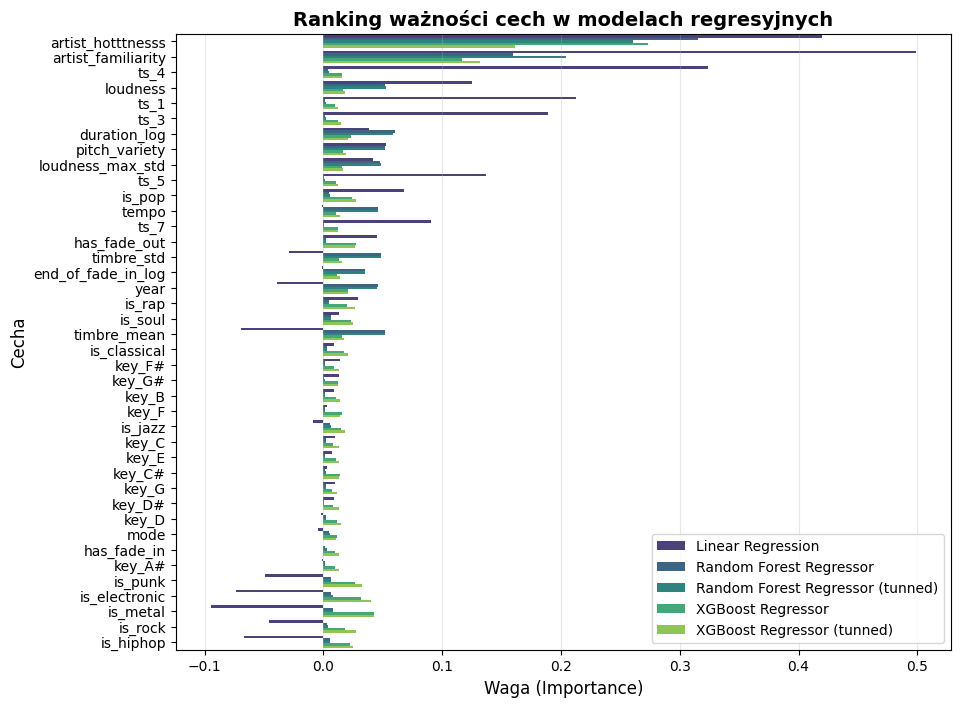

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=r_pivot_df.reset_index().melt(id_vars='Feature', var_name='Model', value_name='Importance'), x='Importance', y='Feature', hue='Model', palette='viridis')

plt.title('Ranking ważności cech w modelach regresyjnych', fontweight='bold', fontsize=14)
plt.xlabel('Waga (Importance)', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
r_df_agg = r_feature_importance_df.copy()
r_df_agg['Category'] = r_df_agg['Feature'].map(feature_categories)

r_df_total = r_df_agg.groupby(['Model', 'Category'])['Importance'].sum().reset_index()

category_order = r_df_total.groupby('Category')['Importance'].mean().sort_values(ascending=False).index

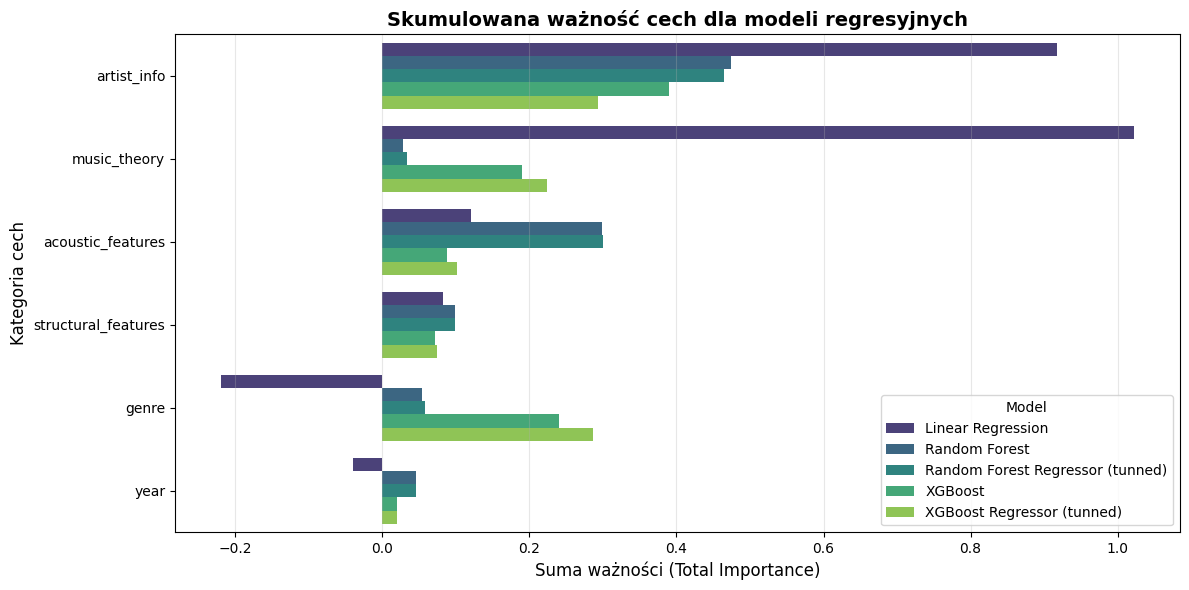

In [ ]:
# wykres
plt.figure(figsize=(12, 6))
sns.barplot(data=r_df_total, x='Importance', y='Category', hue='Model', 
            order=category_order, palette='viridis')
plt.title('Skumulowana ważność cech dla modeli regresyjnych', fontsize=14, fontweight='bold')
plt.xlabel('Suma ważności (Total Importance)', fontsize=12)
plt.ylabel('Kategoria cech', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()

# OSTATECZNE porównanie trafości predykcji

C:\Users\48726\AppData\Local\Temp\ipykernel_14848\1167275438.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


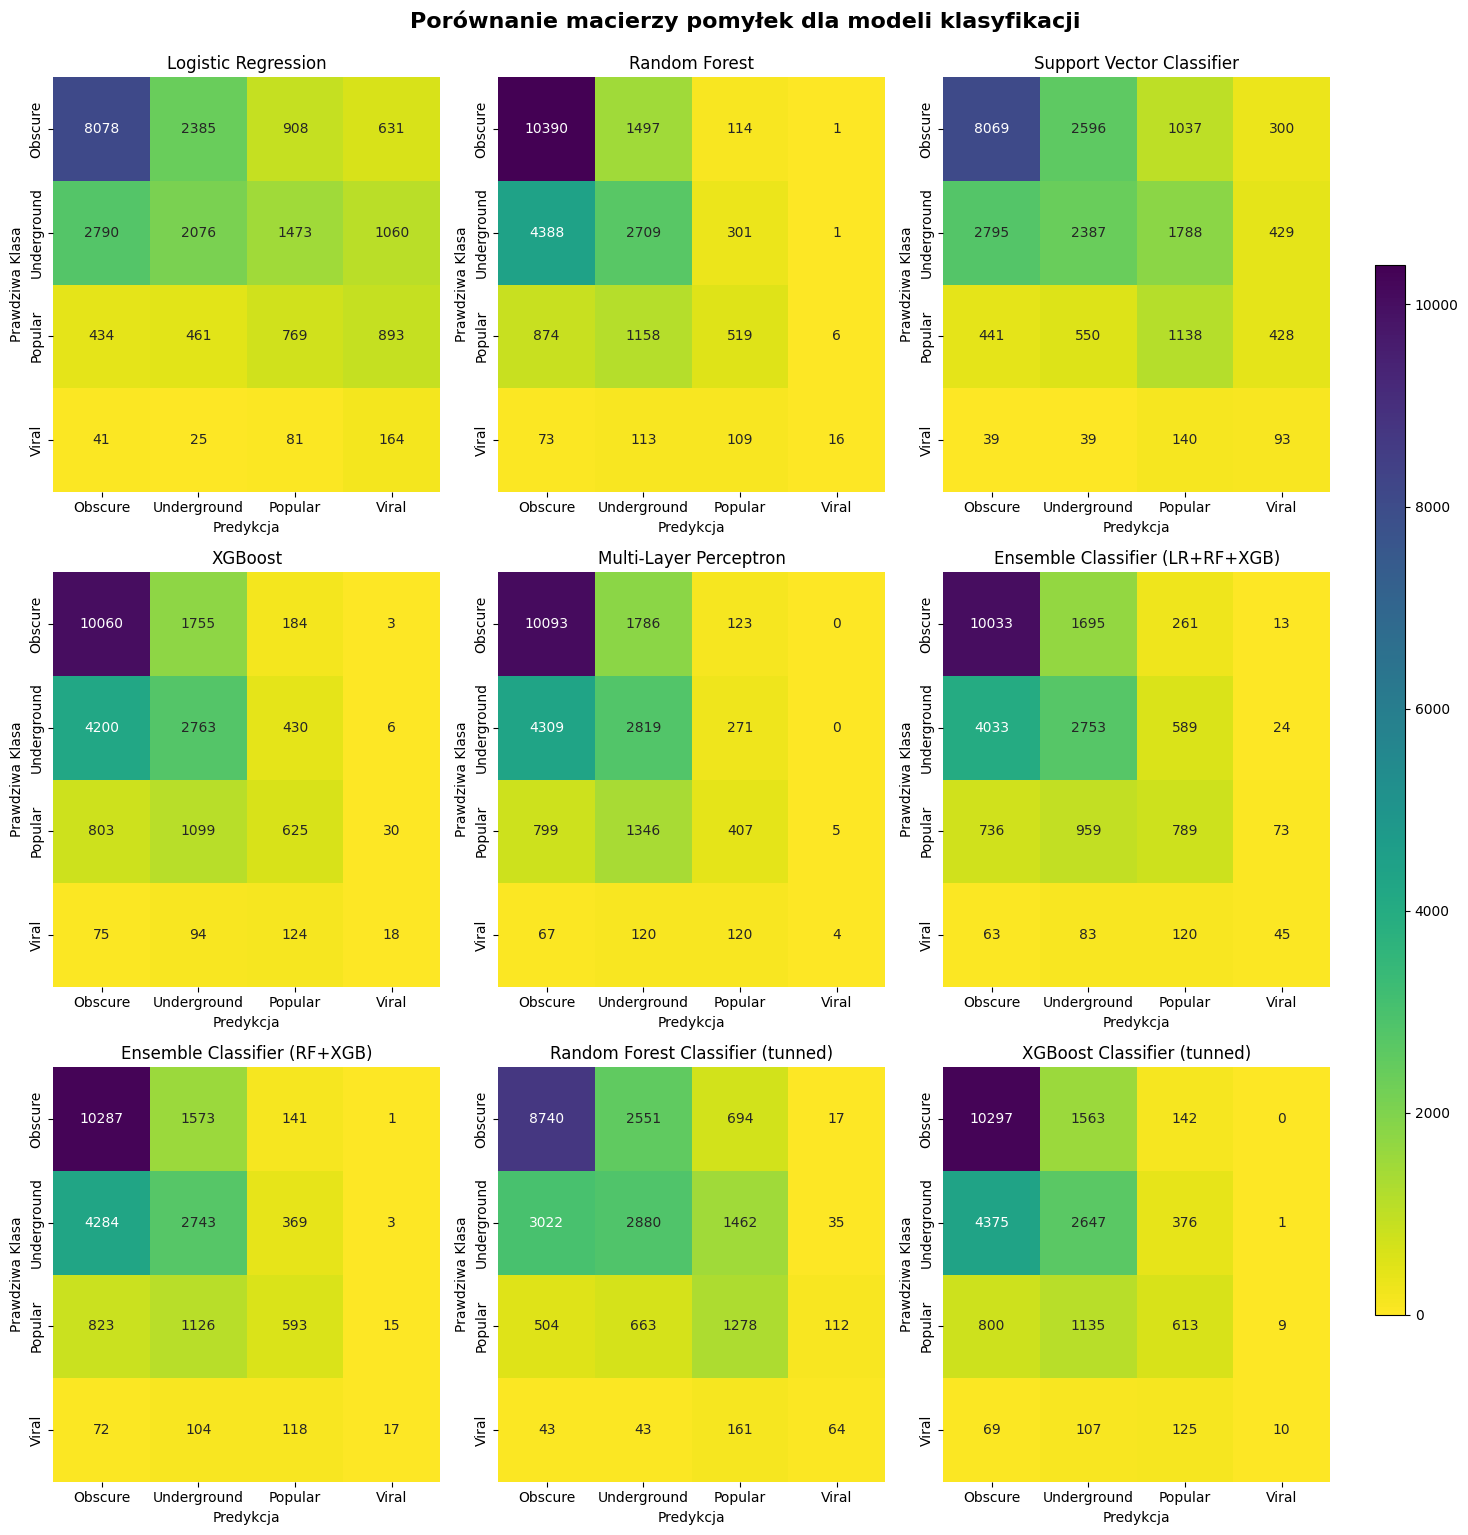

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

labels = ['Obscure', 'Underground', 'Popular', 'Viral']

all_CMs = [
    (cm_cLogR, 'Logistic Regression'),
    (cm_cRF, 'Random Forest'),
    (cm_cSVM, 'Support Vector Classifier'),
    (cm_cXGB, 'XGBoost'),
    (cm_cMLP, 'Multi-Layer Perceptron'),
    (cm_ens, 'Ensemble Classifier (LR+RF+XGB)'),
    (cm_ens2, 'Ensemble Classifier (RF+XGB)'),
    (cm_cRFt, 'Random Forest Classifier (tunned)'),
    (cm_cXGBt, 'XGBoost Classifier (tunned)'),

]

# znajdujemy największą wartość we wszystkich macierzach, żeby ułatwić porównanie
max_val = max([cm.max() for cm, _ in all_CMs])


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

axes_flat = axes.flatten()

for i, (cm, model_name) in enumerate(all_CMs):
    ax = axes_flat[i] 
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis_r',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=max_val, cbar=False, ax=ax)
    
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('Prawdziwa Klasa')
    ax.set_xlabel('Predykcja')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
plt.colorbar(axes_flat[4].collections[0], cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])

fig.suptitle('Porównanie macierzy pomyłek dla modeli klasyfikacji', fontsize=16, fontweight='bold', y=1.02)

plt.savefig('figures/cm_all_models_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\48726\AppData\Local\Temp\ipykernel_14848\968931130.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


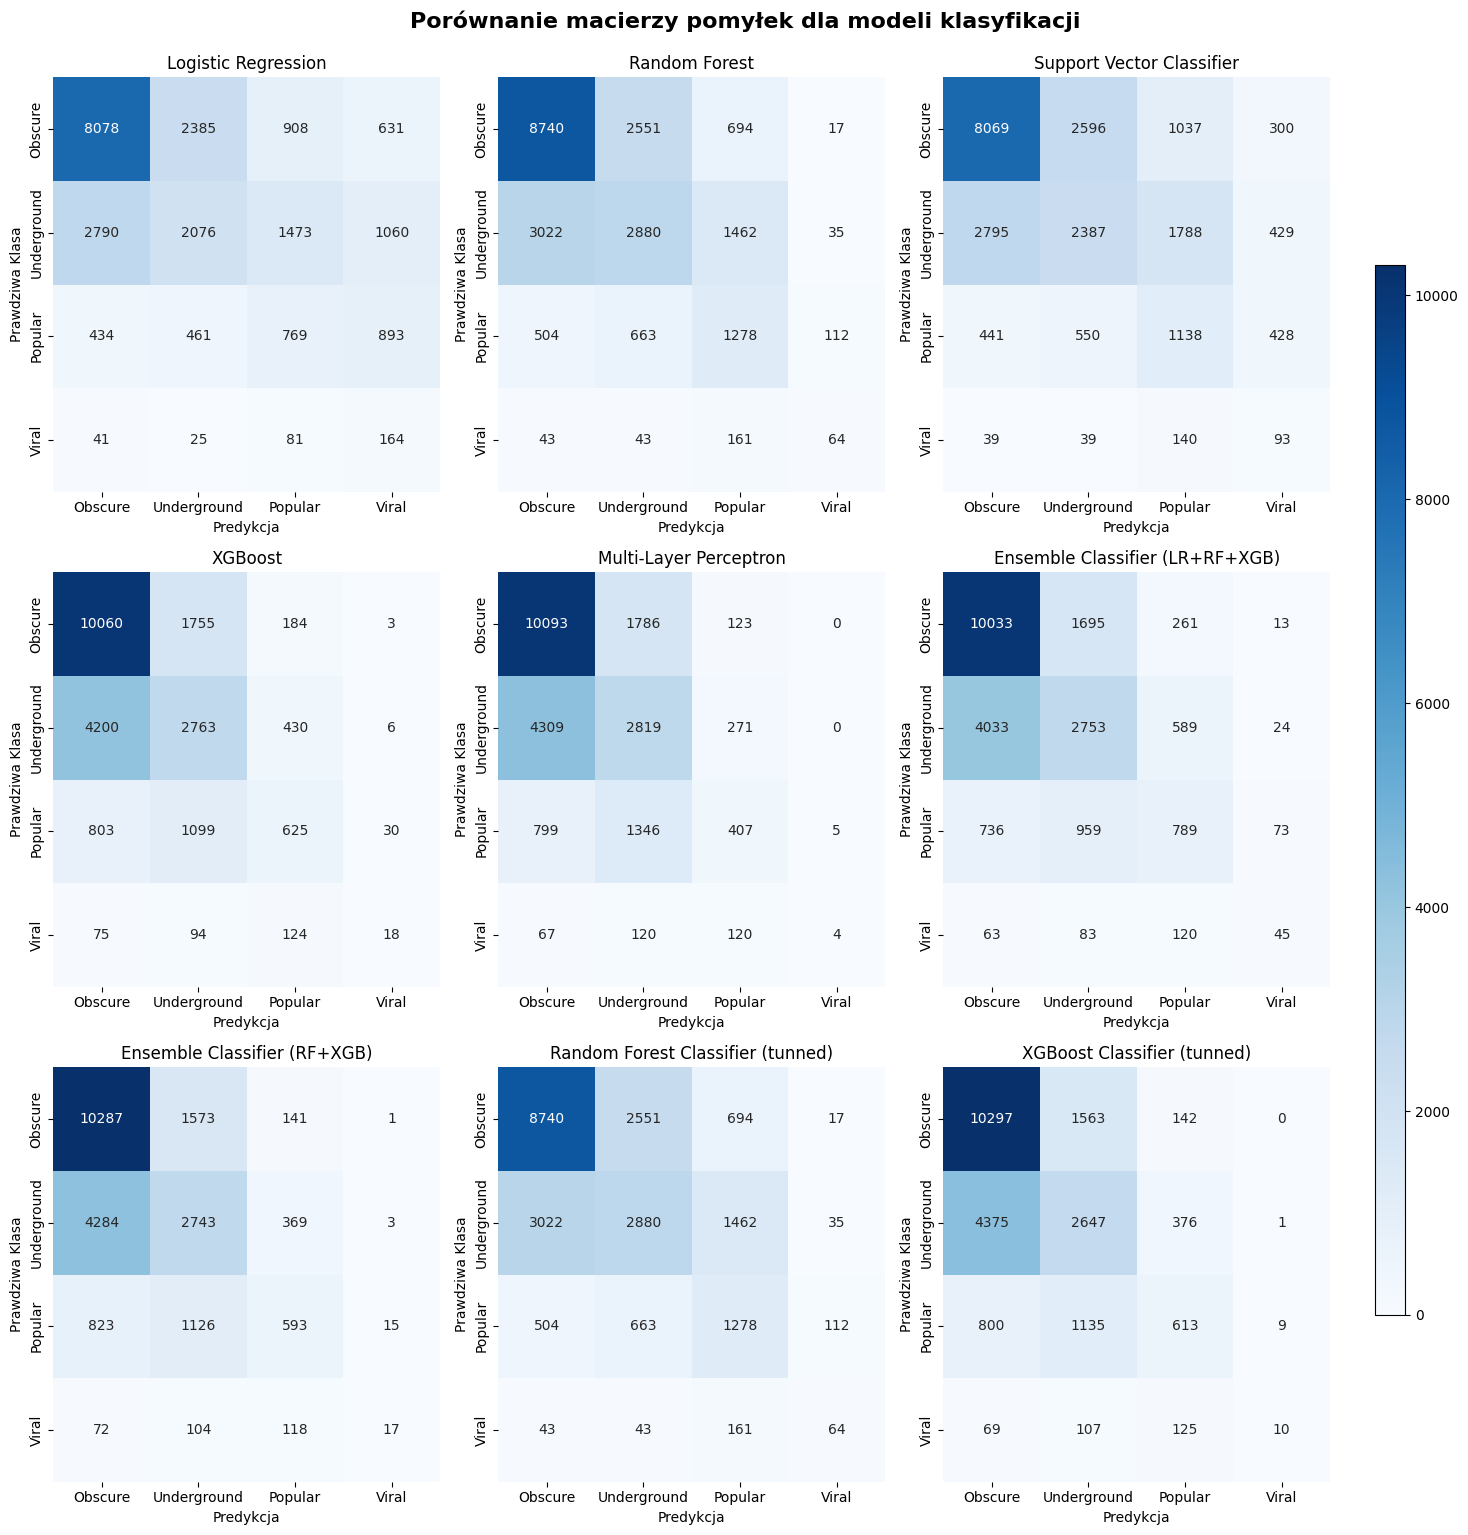

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

labels = ['Obscure', 'Underground', 'Popular', 'Viral']

all_CMs = [
    (cm_cLogR, 'Logistic Regression'),
    (cm_cRF, 'Random Forest'),
    (cm_cSVM, 'Support Vector Classifier'),
    (cm_cXGB, 'XGBoost'),
    (cm_cMLP, 'Multi-Layer Perceptron'),
    (cm_ens, 'Ensemble Classifier (LR+RF+XGB)'),
    (cm_ens2, 'Ensemble Classifier (RF+XGB)'),
    (cm_cRFt, 'Random Forest Classifier (tunned)'),
    (cm_cXGBt, 'XGBoost Classifier (tunned)'),

]

# znajdujemy największą wartość we wszystkich macierzach, żeby ułatwić porównanie
max_val = max([cm.max() for cm, _ in all_CMs])


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

axes_flat = axes.flatten()

for i, (cm, model_name) in enumerate(all_CMs):
    ax = axes_flat[i] 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=max_val, cbar=False, ax=ax)
    
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('Prawdziwa Klasa')
    ax.set_xlabel('Predykcja')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
plt.colorbar(axes_flat[4].collections[0], cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])

fig.suptitle('Porównanie macierzy pomyłek dla modeli klasyfikacji', fontsize=16, fontweight='bold', y=1.02)

plt.savefig('figures/cm_all_models_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
y_pred_rXGB = model_rXGB.predict(X_test_r_scaled)
y_pred_rRF = model_rRF.predict(X_test_r_scaled)

y_pred_rXGBt = best_xgb.predict(X_test_r_scaled)
y_pred_rRFt = best_rf.predict(X_test_r_scaled)

c:\Users\48726\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\48726\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


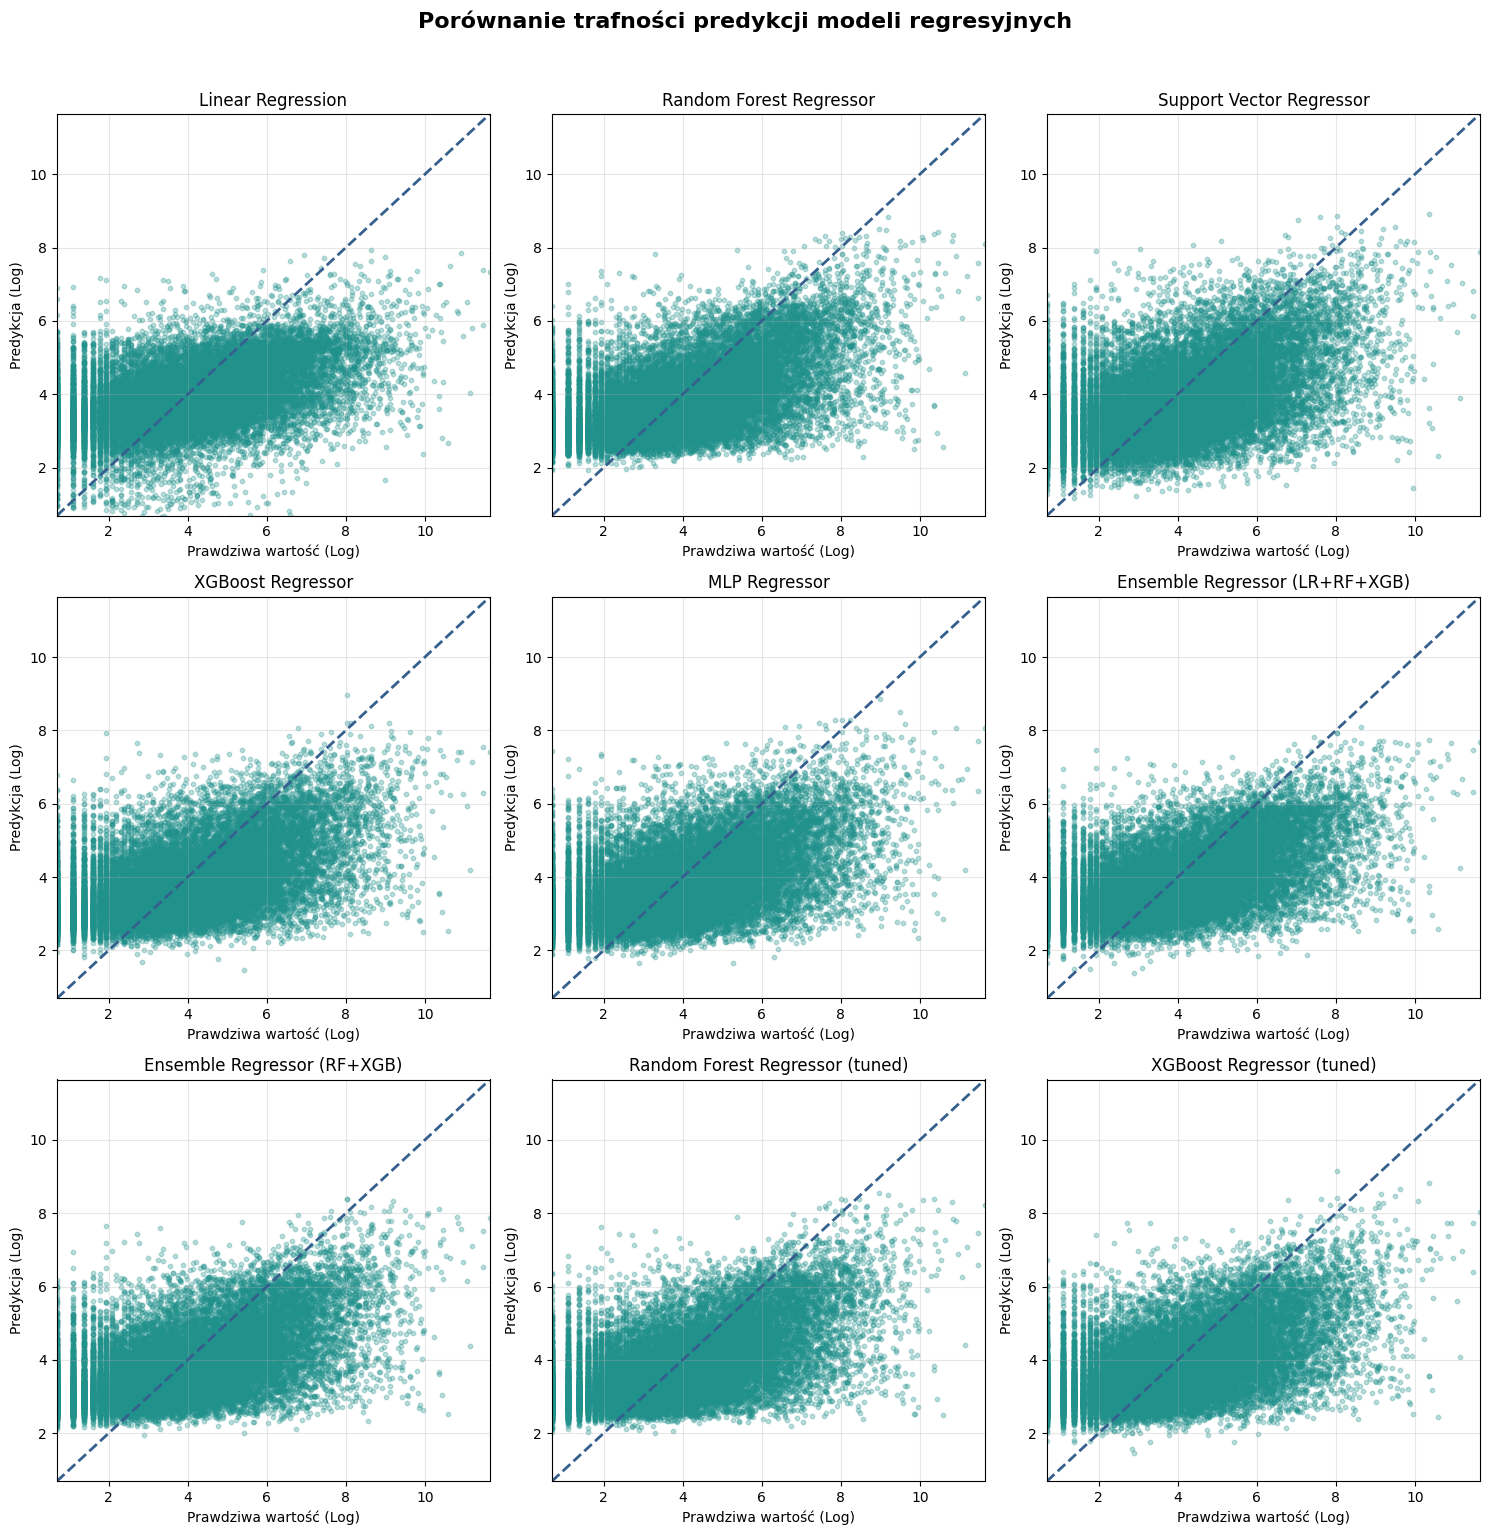

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

reg_models = [
    (y_pred_rLinR, 'Linear Regression'),
    (y_pred_rRF, 'Random Forest Regressor'),
    (y_pred_rSVM, 'Support Vector Regressor'),
    (y_pred_rXGB, 'XGBoost Regressor'),
    (y_pred_rMLP, 'MLP Regressor'),
    (y_pred_voting_r, 'Ensemble Regressor (LR+RF+XGB)'),
    (y_pred_voting_r_2, 'Ensemble Regressor (RF+XGB)'),
    (y_pred_rRFt, 'Random Forest Regressor (tuned)'),
    (y_pred_rXGBt, 'XGBoost Regressor (tuned)')
    
]

n_models = len(reg_models)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes_flat = axes.flatten()

min_val = y_test_r.min()
max_val = y_test_r.max()

dot_color = plt.cm.viridis(0.5) 
line_color = plt.cm.viridis(0.3) 

for i, (y_pred, model_name) in enumerate(reg_models):
    ax = axes_flat[i]
    
    ax.scatter(y_test_r, y_pred, alpha=0.3, color=dot_color, s=10)
    
    ax.plot([min_val, max_val], [min_val, max_val], color=line_color, linestyle='--', linewidth=2)
    
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel('Prawdziwa wartość (Log)')
    ax.set_ylabel('Predykcja (Log)')
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Porównanie trafności predykcji modeli regresyjnych', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('figures/regression_comparison_scatter.png', bbox_inches='tight', dpi=300)
plt.show()